# Notebook 7B — Visualisations supplémentaires

Complément du Notebook 7. Ce notebook ajoute **19 figures** supplémentaires, toujours construites
**uniquement à partir des fichiers réels** du dossier `processed/` (aucune valeur inventée), et
enregistrées dans `figures/`.

| Groupe | Figures ajoutées |
|---|---|
| **A** | Les 9 polluants, CO₂ par heure/jour, couverture des données, distributions labo vs appartement |
| **B** | Hiérarchie de classes, exemple d'instance SOSA+QUDT, table variable→classe→unité |
| **C** | Graphe par degré, matrice d'adjacence, sous-graphe des polluants |
| **D** | Seuils MAD sur 3 modèles, distributions d'erreur, **courbes ROC & PR**, matrice de confusion |
| **E** | RMSE & MAE par polluant, meilleur modèle par polluant, distribution des cibles réelles |

> Les courbes ROC/PR (groupe D) sont **recalculées à partir des erreurs de reconstruction
> sauvegardées** (`recon_errors.npz`) — l'AUC du GCN retrouvée (≈ 0,556) coïncide avec celle du
> Notebook 4, ce qui valide la cohérence.


In [1]:
# -*- coding: utf-8 -*-
"""Notebook 7B — figures supplémentaires. Test contre données réelles."""
import os, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyBboxPatch, FancyArrowPatch
import matplotlib.dates as mdates
import networkx as nx
warnings.filterwarnings("ignore")

PROC = Path("processed"); GRAPH = PROC/"graph"; ONTO = PROC/"ontology"
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":150,"savefig.bbox":"tight",
    "font.size":11,"axes.titlesize":13,"axes.titleweight":"bold","axes.grid":True,
    "grid.alpha":0.25,"axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
CAT_COLORS={"Pollutant":"#d64545","ParticleMatter":"#e08a3c","ParticleCount":"#f0c419",
    "EnvironmentalCondition":"#2e86c1","DynamicCondition":"#16a085","AcousticCondition":"#8e44ad",
    "AssessmentMetric":"#7f8c8d","MeasurementProperty":"#34495e"}
EVENT_COLORS={"fire":"#e74c3c","dust_humidity":"#f39c12","power_outage":"#2c3e50"}
EVENT_FR={"fire":"Incendie","dust_humidity":"Erreur poussière/humidité","power_outage":"Coupure de courant","normal":"Normal"}
def lj(p):
    with open(p,encoding="utf-8") as f: return json.load(f)
cfg=lj(PROC/"config.json"); onto_rep=lj(ONTO/"ontology_report.json"); gman=lj(GRAPH/"graph_manifest.json")
events=cfg["events"]; cat=cfg["category"]; units=cfg["units"]
def save(fig,name):
    fig.savefig(FIG/name); plt.show(); print("figure :",FIG/name); return name
done=[]
def t(fn):
    try: done.append(fn())
    except Exception as e: print("  ✗",fn.__name__,"->",repr(e))

lab=pd.read_csv(PROC/"laboratory_clean.csv",parse_dates=["timestamp"])
apt=pd.read_csv(PROC/"apartment_clean.csv",parse_dates=["timestamp"])
def ev_span(n):
    e=next(x for x in events if x["name"]==n); return pd.Timestamp(e["start"]),pd.Timestamp(e["end"])

TARGETS=gman["prediction"]["targets"]  # 9 polluants

## Groupe A — Données (figures supplémentaires)

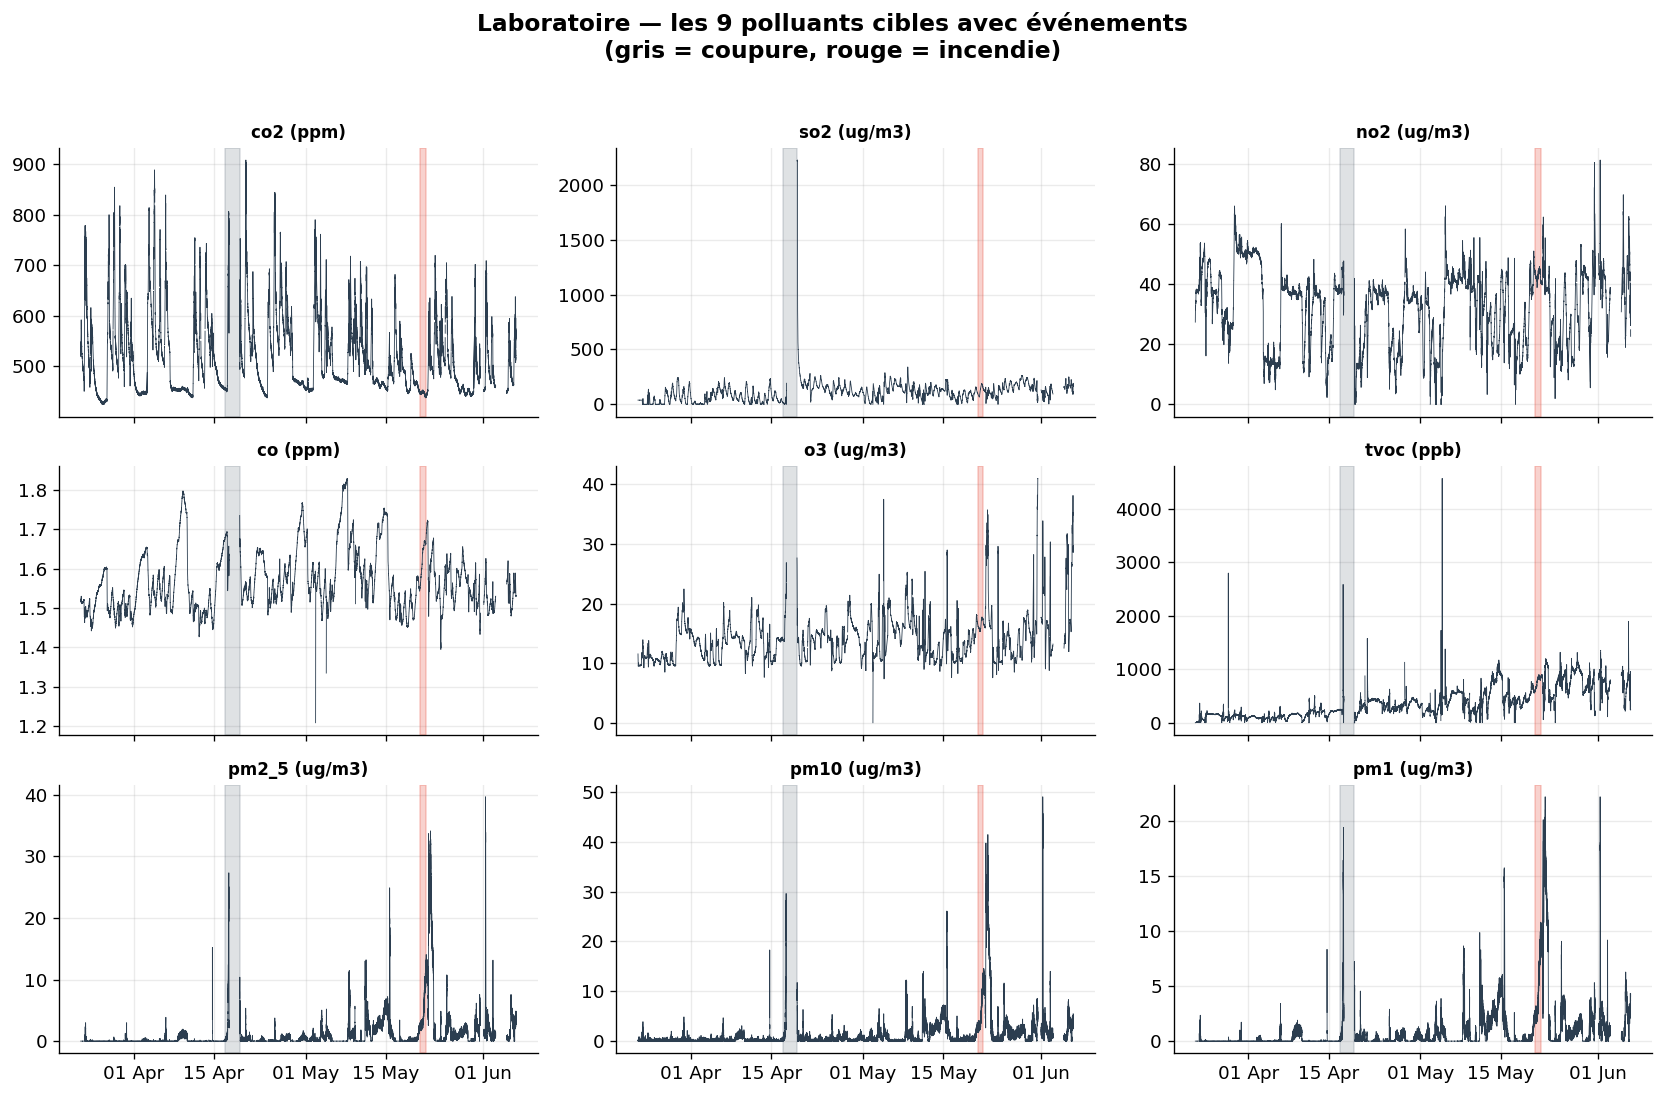

figure : figures\A7_tous_polluants.png


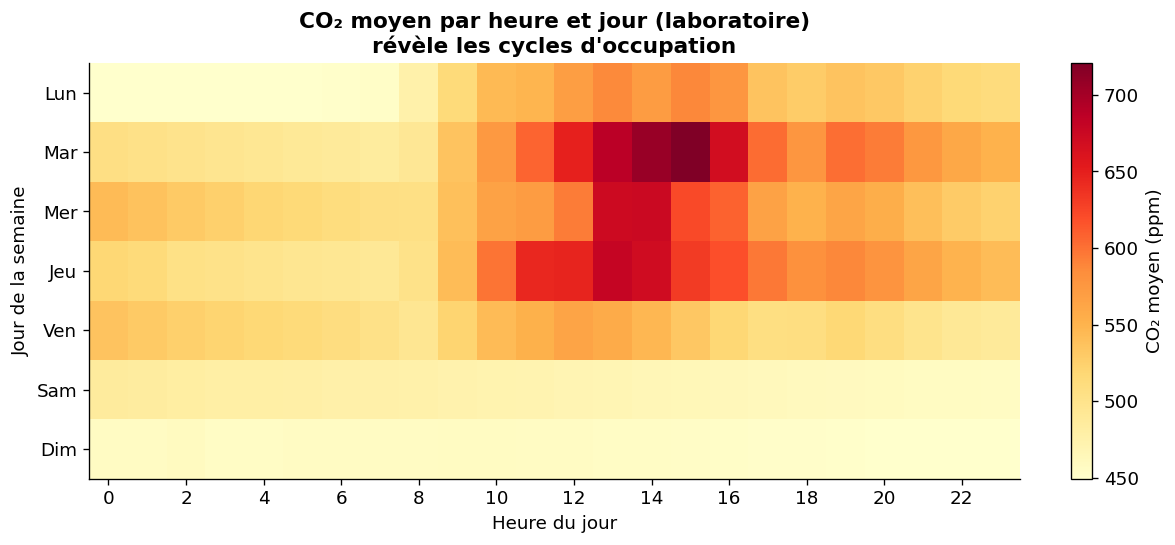

figure : figures\A8_co2_heure_jour.png


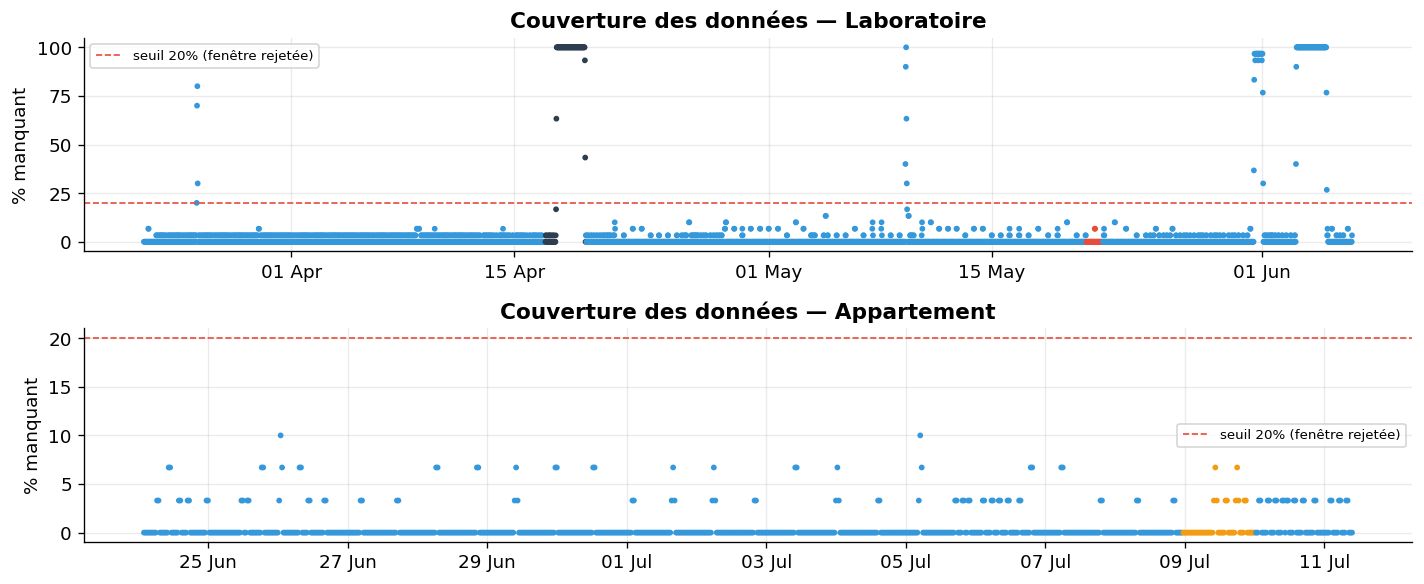

figure : figures\A9_couverture_donnees.png


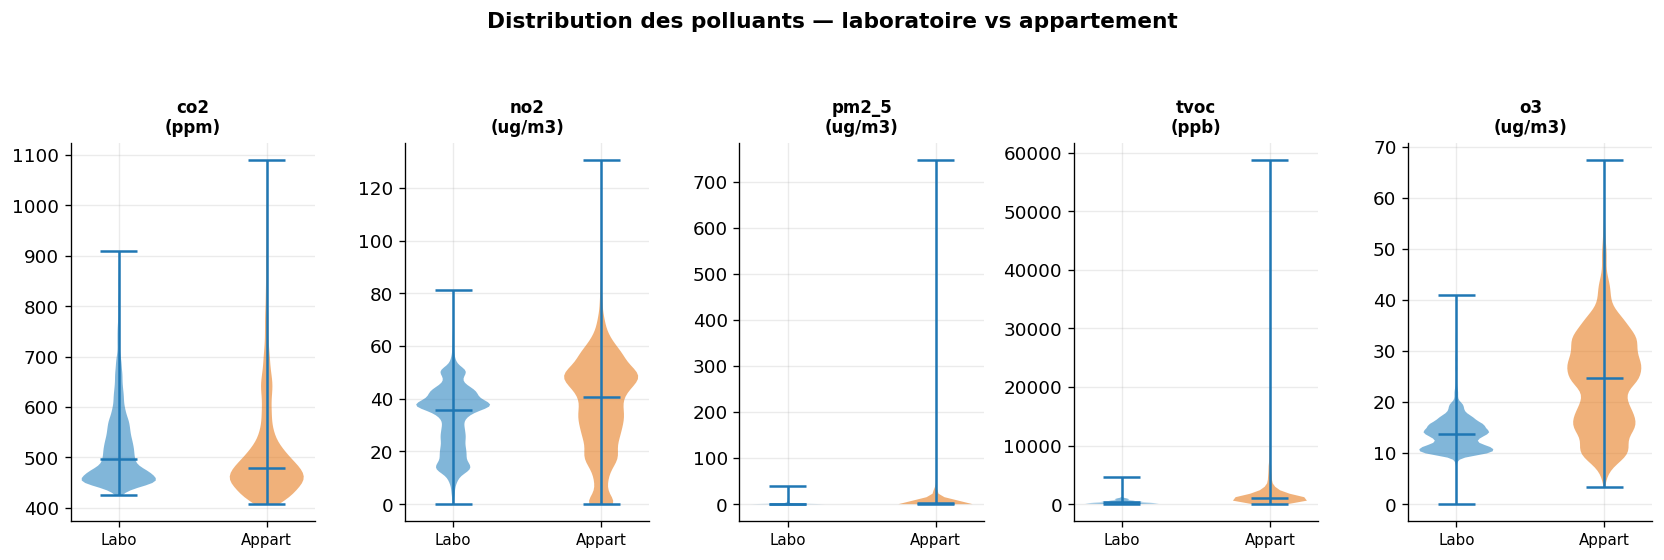

figure : figures\A10_distributions_labo_appart.png


In [2]:
def A7_all_pollutants():
    po_s,po_e=ev_span("power_outage"); fi_s,fi_e=ev_span("fire")
    fig,axes=plt.subplots(3,3,figsize=(14,9),sharex=True)
    for ax,c in zip(axes.ravel(),TARGETS):
        ax.plot(lab["timestamp"],lab[c],lw=0.5,color="#2c3e50")
        ax.axvspan(po_s,po_e,color=EVENT_COLORS["power_outage"],alpha=0.15)
        ax.axvspan(fi_s,fi_e,color=EVENT_COLORS["fire"],alpha=0.25)
        ax.set_title(f"{c} ({units.get(c,'')})",fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    fig.suptitle("Laboratoire — les 9 polluants cibles avec événements\n(gris = coupure, rouge = incendie)",
                 fontsize=14,fontweight="bold",y=1.01)
    fig.tight_layout(rect=[0,0,1,0.99])
    return save(fig,"A7_tous_polluants.png")

def A8_hour_heatmap():
    d=lab.copy(); d["h"]=d["timestamp"].dt.hour; d["dow"]=d["timestamp"].dt.dayofweek
    piv=d.pivot_table(index="dow",columns="h",values="co2",aggfunc="mean")
    days=["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]
    fig,ax=plt.subplots(figsize=(11,4.5))
    im=ax.imshow(piv,cmap="YlOrRd",aspect="auto")
    ax.set_yticks(range(7)); ax.set_yticklabels(days)
    ax.set_xticks(range(0,24,2)); ax.set_xticklabels(range(0,24,2))
    ax.set_xlabel("Heure du jour"); ax.set_ylabel("Jour de la semaine")
    ax.set_title("CO₂ moyen par heure et jour (laboratoire)\nrévèle les cycles d'occupation"); ax.grid(False)
    fig.colorbar(im,ax=ax,fraction=0.04,label="CO₂ moyen (ppm)")
    return save(fig,"A8_co2_heure_jour.png")

def A9_gap_map():
    w=pd.read_csv(PROC/"windows.csv",parse_dates=["start"])
    fig,axes=plt.subplots(2,1,figsize=(12,5),sharex=False)
    for ax,(loc,title) in zip(axes,[("laboratory","Laboratoire"),("apartment","Appartement")]):
        sub=w[w["location"]==loc].sort_values("start")
        colors=sub["event"].map(lambda e:EVENT_COLORS.get(e,"#3498db"))
        ax.scatter(sub["start"],sub["gap_frac"]*100,s=6,c=colors)
        ax.axhline(20,ls="--",color="#e74c3c",lw=1,label="seuil 20% (fenêtre rejetée)")
        ax.set_ylabel("% manquant"); ax.set_title(f"Couverture des données — {title}")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b")); ax.legend(fontsize=8)
    fig.tight_layout()
    return save(fig,"A9_couverture_donnees.png")

def A10_violin():
    polls=["co2","no2","pm2_5","tvoc","o3"]
    fig,axes=plt.subplots(1,len(polls),figsize=(14,4.5))
    for ax,c in zip(axes,polls):
        data=[lab[c].dropna().values,apt[c].dropna().values]
        parts=ax.violinplot(data,showmedians=True)
        for i,pc in enumerate(parts['bodies']):
            pc.set_facecolor(["#2e86c1","#e67e22"][i]); pc.set_alpha(0.6)
        ax.set_xticks([1,2]); ax.set_xticklabels(["Labo","Appart"],fontsize=9)
        ax.set_title(f"{c}\n({units.get(c,'')})",fontsize=10)
    fig.suptitle("Distribution des polluants — laboratoire vs appartement",
                 fontsize=13,fontweight="bold",y=1.03); fig.tight_layout(rect=[0,0,1,0.98])
    return save(fig,"A10_distributions_labo_appart.png")

# ===================== B-series =====================

for f in [A7_all_pollutants,A8_hour_heatmap,A9_gap_map,A10_violin]: f()

## Groupe B — Ontologie (figures supplémentaires)

**B3** : la hiérarchie complète des classes (taxonomie `subClassOf`). **B4** : un exemple concret
d'instance suivant le patron **SOSA + QUDT** (une observation de NO₂ reliée à sa propriété, sa
grandeur physique et son unité). **B5** : la table variable → classe ontologique → unité.

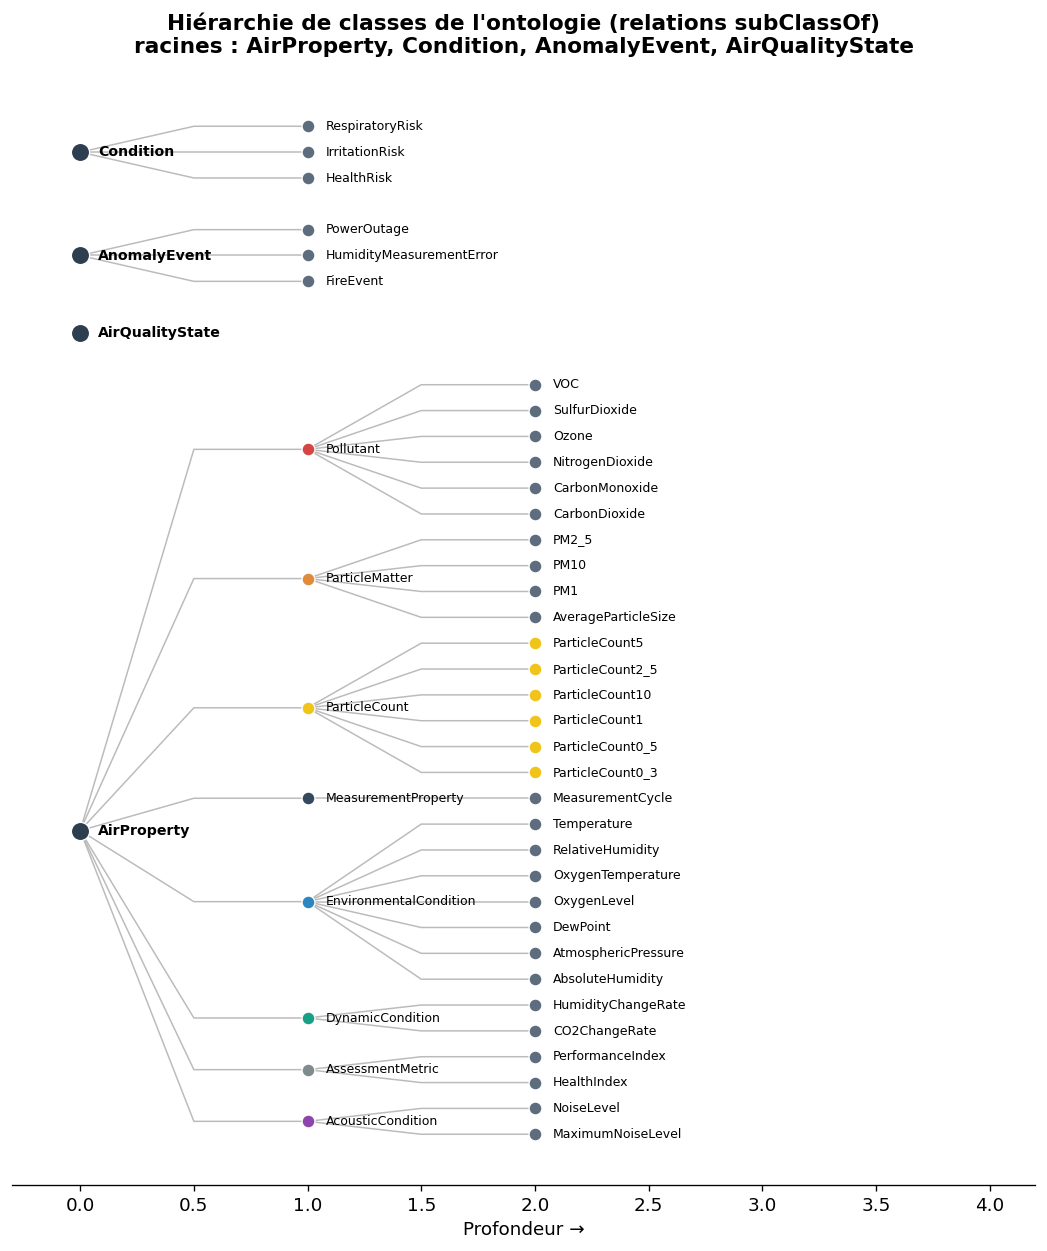

figure : figures\B3_hierarchie_classes.png


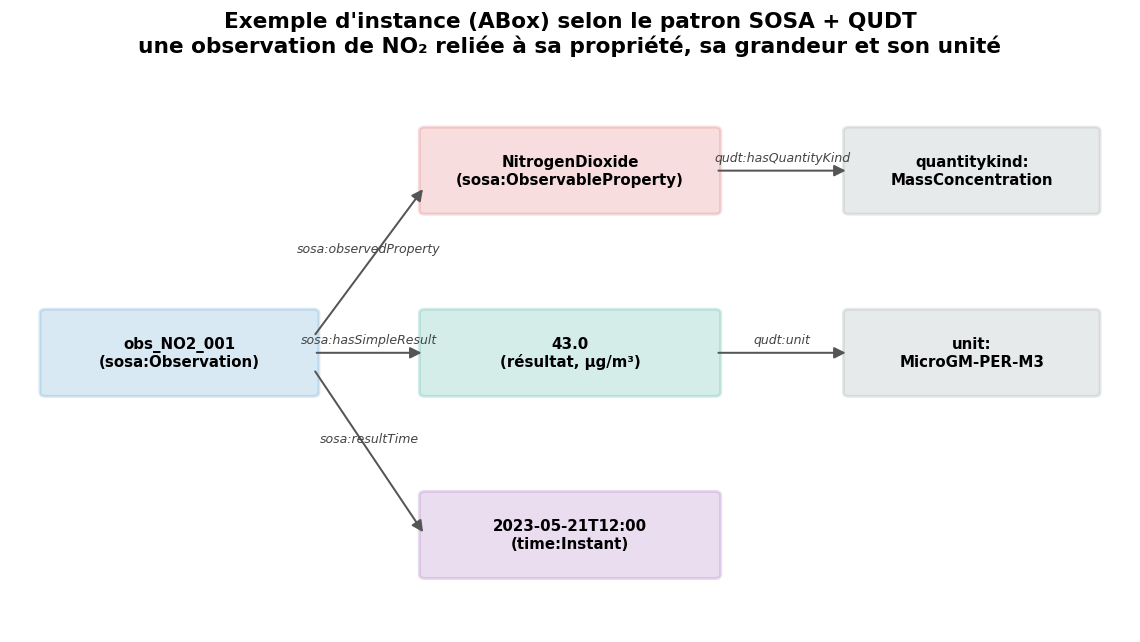

figure : figures\B4_exemple_abox_sosa.png


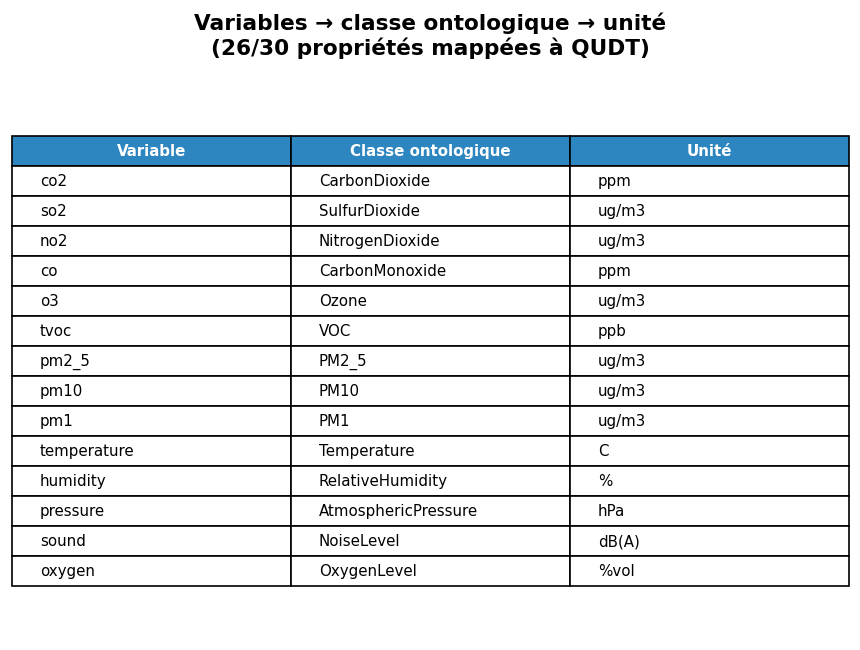

figure : figures\B5_table_unites_qudt.png


In [3]:
import rdflib  # requis pour le groupe B
def _onto_graph():
    import rdflib
    from rdflib import RDFS,RDF,OWL
    g=rdflib.Graph(); g.parse(ONTO/"iaq_ontology.ttl",format="turtle")
    def nm(u): return str(u).split("#")[-1].split("/")[-1]
    H=nx.DiGraph()
    for s,o in g.subject_objects(RDFS.subClassOf):
        if isinstance(o,rdflib.URIRef) and isinstance(s,rdflib.URIRef):
            sn,on=nm(s),nm(o)
            if sn and on and not on.startswith("n") and "Restriction" not in on:
                H.add_edge(on,sn)
    return H,g,nm

def B3_hierarchy():
    H,_,_=_onto_graph()
    keep=set()
    for root in ["AirProperty","Condition","AnomalyEvent","AirQualityState"]:
        if root in H:
            keep.add(root); keep|=nx.descendants(H,root)
    Hs=H.subgraph(keep).copy()
    roots=[n for n in Hs if Hs.in_degree(n)==0]
    # ---- tidy-tree : y par ordre des feuilles, x par profondeur ----
    pos={}; counter=[0]
    visited=set()
    def place(node,depth):
        if node in visited:  # éviter cycles/diamants
            return pos[node][1]
        visited.add(node)
        children=sorted(Hs.successors(node))
        if not children:
            y=counter[0]; counter[0]+=1
        else:
            ys=[place(c,depth+1) for c in children]
            y=sum(ys)/len(ys)
        pos[node]=(depth,y)
        return y
    for r in sorted(roots): place(r,0); counter[0]+=1  # espace entre arbres
    fig,ax=plt.subplots(figsize=(11,12))
    def colof(n):
        for k in CAT_COLORS:
            base=k.replace("Condition","").replace("Metric","").lower()
            if base and base in n.lower(): return CAT_COLORS[k]
        if n in roots: return "#2c3e50"
        return "#5d6d7e"
    for u,v in Hs.edges():
        if u in pos and v in pos:
            x1,y1=pos[u]; x2,y2=pos[v]
            ax.plot([x1,x1+0.5,x2],[y1,y2,y2],color="#bbb",lw=0.9,zorder=1)
    for n,(x,y) in pos.items():
        is_root=n in roots
        ax.scatter([x],[y],s=120 if is_root else 60,color=colof(n),zorder=2,
                   edgecolors="white",linewidths=0.8)
        ax.text(x+0.08,y,n,va="center",fontsize=8.5 if is_root else 7.5,
                fontweight="bold" if is_root else "normal")
    ax.set_title("Hiérarchie de classes de l'ontologie (relations subClassOf)\n"
                 "racines : AirProperty, Condition, AnomalyEvent, AirQualityState",pad=14)
    ax.set_xlabel("Profondeur →"); ax.set_yticks([]); ax.set_xlim(-0.3, max(p[0] for p in pos.values())+2.2)
    ax.spines["left"].set_visible(False); ax.grid(False)
    return save(fig,"B3_hierarchie_classes.png")

def B4_abox_sample():
    """Diagramme du patron SOSA pour une observation de NO2."""
    fig,ax=plt.subplots(figsize=(12,6)); ax.axis("off"); ax.set_xlim(0,10); ax.set_ylim(0,7)
    def box(x,y,w,h,txt,color):
        ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.05",
                     facecolor=color,alpha=0.18,edgecolor=color,lw=1.8))
        ax.text(x+w/2,y+h/2,txt,ha="center",va="center",fontsize=9,fontweight="bold")
    def arrow(x1,y1,x2,y2,label):
        ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle="-|>",mutation_scale=14,color="#555",lw=1.2))
        ax.text((x1+x2)/2,(y1+y2)/2+0.12,label,ha="center",fontsize=7.5,style="italic",color="#444")
    box(0.3,3,2.4,1,"obs_NO2_001\n(sosa:Observation)","#2e86c1")
    box(3.7,5.3,2.6,1,"NitrogenDioxide\n(sosa:ObservableProperty)","#d64545")
    box(3.7,3,2.6,1,"43.0\n(résultat, µg/m³)","#16a085")
    box(3.7,0.7,2.6,1,"2023-05-21T12:00\n(time:Instant)","#8e44ad")
    box(7.5,5.3,2.2,1,"quantitykind:\nMassConcentration","#7f8c8d")
    box(7.5,3,2.2,1,"unit:\nMicroGM-PER-M3","#7f8c8d")
    arrow(2.7,3.7,3.7,5.6,"sosa:observedProperty")
    arrow(2.7,3.5,3.7,3.5,"sosa:hasSimpleResult")
    arrow(2.7,3.3,3.7,1.2,"sosa:resultTime")
    arrow(6.3,5.8,7.5,5.8,"qudt:hasQuantityKind")
    arrow(6.3,3.5,7.5,3.5,"qudt:unit")
    ax.set_title("Exemple d'instance (ABox) selon le patron SOSA + QUDT\n"
                 "une observation de NO₂ reliée à sa propriété, sa grandeur et son unité",pad=14)
    return save(fig,"B4_exemple_abox_sosa.png")

def B5_qudt_table():
    oc=cfg["ontology_class"]
    rows=[]
    for v in TARGETS+["temperature","humidity","pressure","sound","oxygen"]:
        rows.append([v,oc.get(v,v),units.get(v,"")])
    fig,ax=plt.subplots(figsize=(9,6)); ax.axis("off")
    tbl=ax.table(cellText=rows,colLabels=["Variable","Classe ontologique","Unité"],
                 loc="center",cellLoc="left")
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1,1.5)
    for j in range(3):
        tbl[0,j].set_facecolor("#2e86c1"); tbl[0,j].set_text_props(color="white",fontweight="bold")
    ax.set_title(f"Variables → classe ontologique → unité\n"
                 f"({onto_rep['observable_properties_qudt_mapped']} propriétés mappées à QUDT)",pad=18)
    return save(fig,"B5_table_unites_qudt.png")

# ===================== C-series =====================

for f in [B3_hierarchy,B4_abox_sample,B5_qudt_table]: f()

## Groupe C — Graphe GNN (figures supplémentaires)

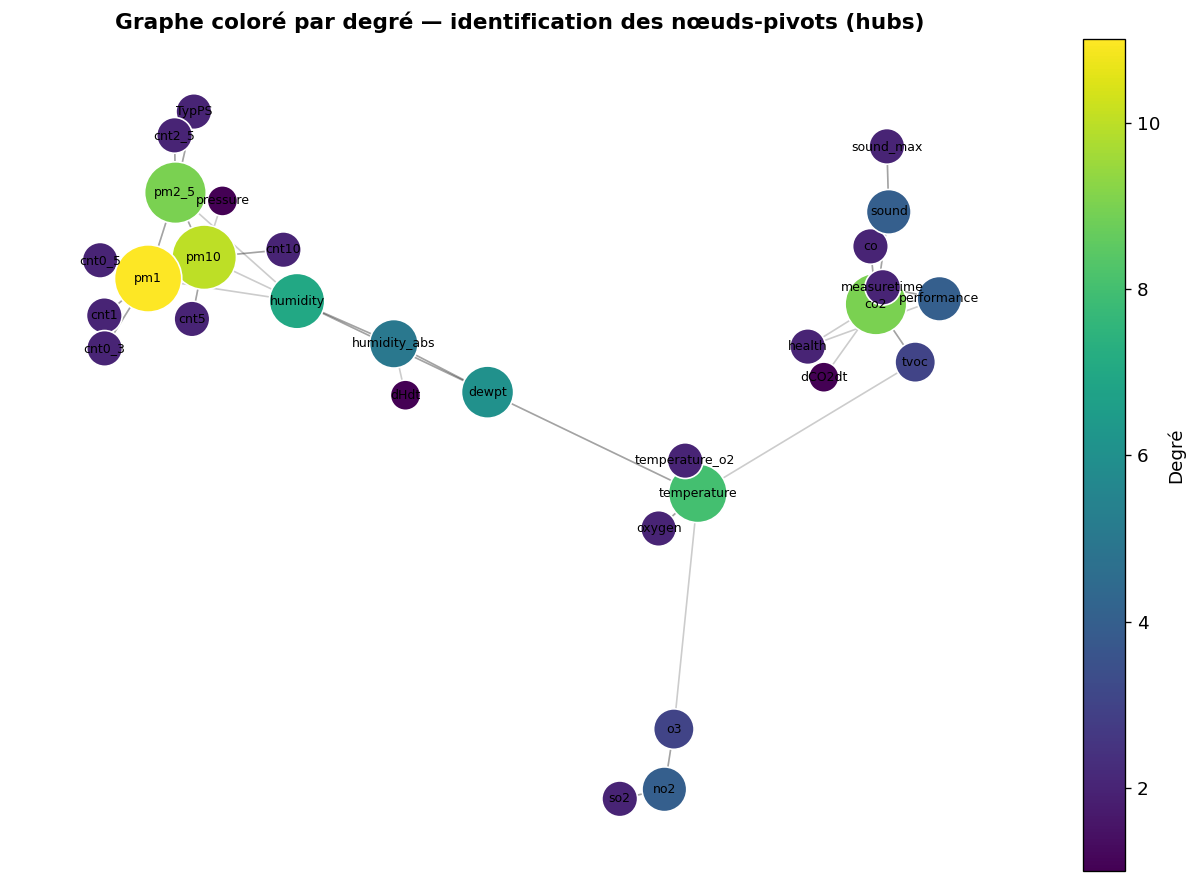

figure : figures\C4_graphe_par_degre.png


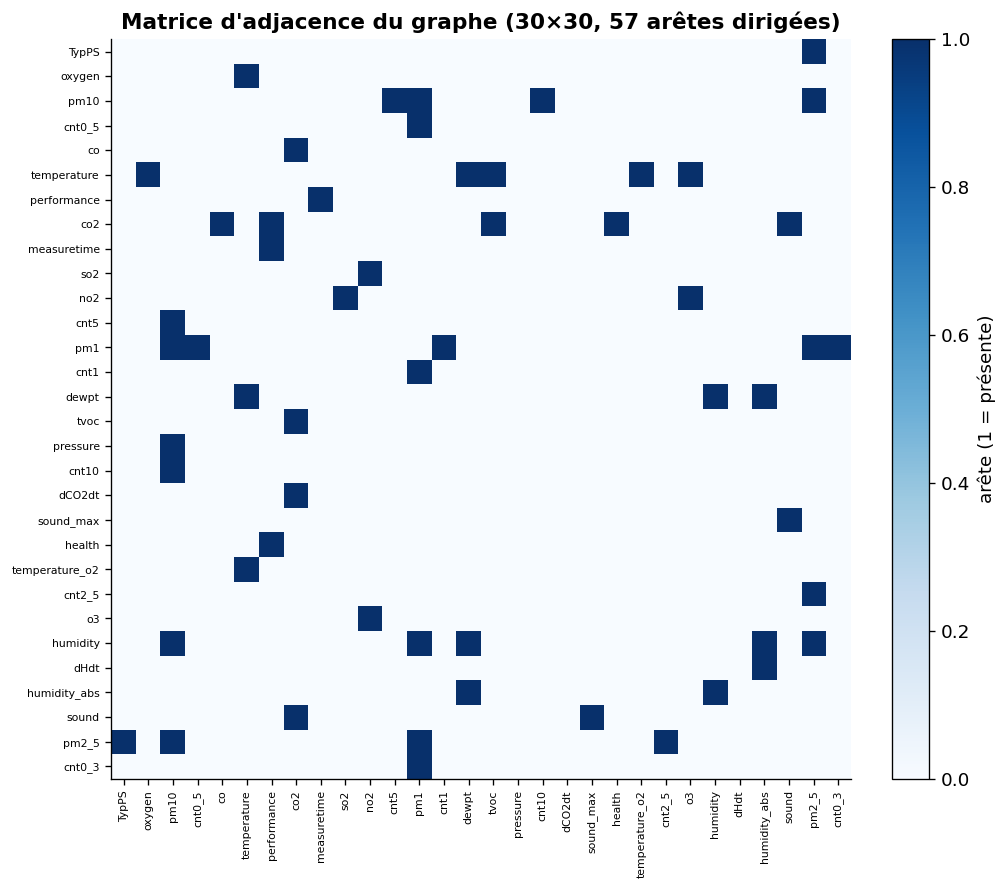

figure : figures\C5_matrice_adjacence.png


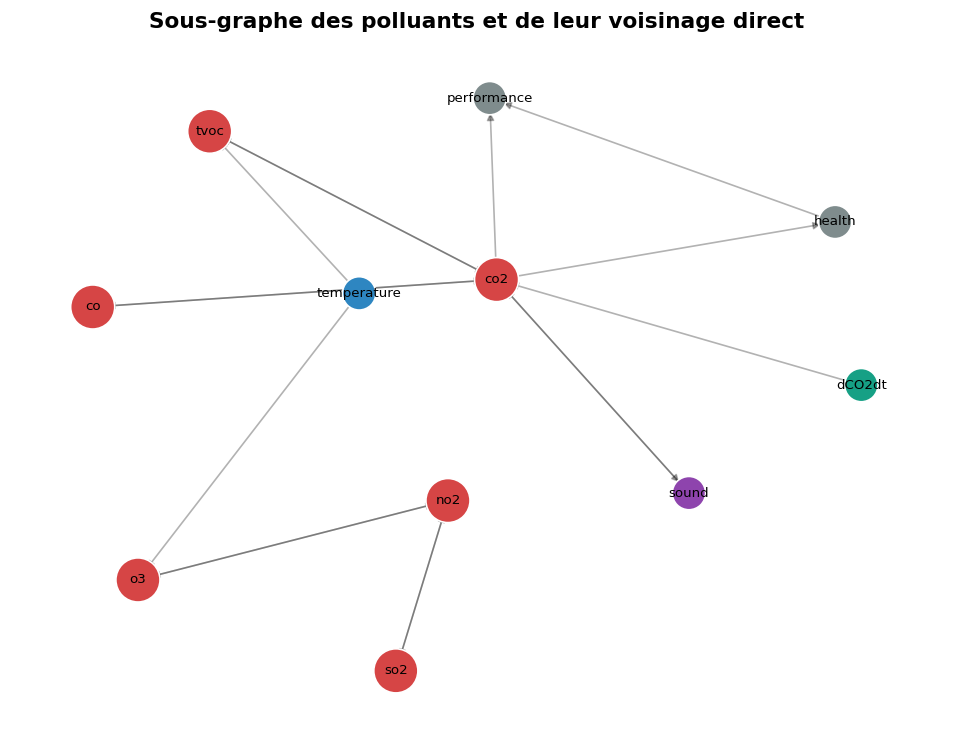

figure : figures\C6_sous_graphe_polluants.png


In [4]:
def _g():
    edges=pd.read_csv(ONTO/"ontology_edges.csv")
    G=nx.DiGraph()
    for n in gman["node_order"]: G.add_node(n,category=cat.get(n,"MeasurementProperty"))
    for _,r in edges.iterrows(): G.add_edge(r["src"],r["dst"],relation=r["relation"])
    return G,edges

def C4_graph_by_degree():
    G,_=_g(); pos=nx.spring_layout(G,seed=42,k=0.9,iterations=200); deg=dict(G.degree())
    fig,ax=plt.subplots(figsize=(12,9))
    nx.draw_networkx_edges(G,pos,ax=ax,alpha=0.2,width=1,arrows=False)
    nodes=nx.draw_networkx_nodes(G,pos,ax=ax,node_color=[deg[n] for n in G.nodes],
        cmap="viridis",node_size=[200+130*deg[n] for n in G.nodes],edgecolors="white",linewidths=1)
    nx.draw_networkx_labels(G,pos,ax=ax,font_size=7.5)
    fig.colorbar(nodes,ax=ax,fraction=0.04,label="Degré")
    ax.set_title("Graphe coloré par degré — identification des nœuds-pivots (hubs)"); ax.axis("off")
    return save(fig,"C4_graphe_par_degre.png")

def C5_adjacency():
    z=np.load(GRAPH/"graph_windows.npz",allow_pickle=True)
    ei=z["edge_index"]; n=len(gman["node_order"]); A=np.zeros((n,n))
    for k in range(ei.shape[1]): A[ei[0,k],ei[1,k]]=1
    order=gman["node_order"]
    fig,ax=plt.subplots(figsize=(9,8))
    im=ax.imshow(A,cmap="Blues",aspect="equal")
    ax.set_xticks(range(n)); ax.set_xticklabels(order,rotation=90,fontsize=6.5)
    ax.set_yticks(range(n)); ax.set_yticklabels(order,fontsize=6.5)
    ax.set_title("Matrice d'adjacence du graphe (30×30, 57 arêtes dirigées)"); ax.grid(False)
    fig.colorbar(im,ax=ax,fraction=0.046,label="arête (1 = présente)")
    return save(fig,"C5_matrice_adjacence.png")

def C6_pollutant_subgraph():
    G,_=_g()
    polls=[n for n in G.nodes if cat.get(n)=="Pollutant"]
    # inclure voisins directs
    keep=set(polls)
    for p in polls: keep|=set(G.predecessors(p))|set(G.successors(p))
    H=G.subgraph(keep).copy()
    pos=nx.spring_layout(H,seed=7,k=1.1)
    fig,ax=plt.subplots(figsize=(10,7.5))
    nx.draw_networkx_edges(H,pos,ax=ax,alpha=0.3,arrows=True,arrowsize=9)
    nx.draw_networkx_nodes(H,pos,ax=ax,node_color=[CAT_COLORS.get(cat.get(n,""),"#999") for n in H],
                           node_size=[700 if cat.get(n)=="Pollutant" else 400 for n in H],
                           edgecolors="white",linewidths=1)
    nx.draw_networkx_labels(H,pos,ax=ax,font_size=8)
    ax.set_title("Sous-graphe des polluants et de leur voisinage direct"); ax.axis("off")
    return save(fig,"C6_sous_graphe_polluants.png")

# ===================== D-series =====================
Z=np.load(GRAPH/"recon_errors.npz",allow_pickle=True)
det_val=Z["det_val"]; det_test=Z["det_test"]; eid=Z["event_id"]
evn={0:"normal",1:"fire",2:"dust_humidity",3:"power_outage"}
MODELS=["GCN","GIN","SAT-Graph"]

for f in [C4_graph_by_degree,C5_adjacency,C6_pollutant_subgraph]: f()

## Groupe D — Détection (figures supplémentaires)

**D7** applique le seuil robuste MAD aux trois modèles : on voit que **SAT-Graph** a la queue la plus
lourde. **D8** superpose les distributions d'erreur normale. **D9/D10** sont les courbes **ROC** et
**précision-rappel** recalculées depuis les erreurs sauvegardées. **D11** est la matrice de confusion
au point d'opération retenu (GCN + MAD).

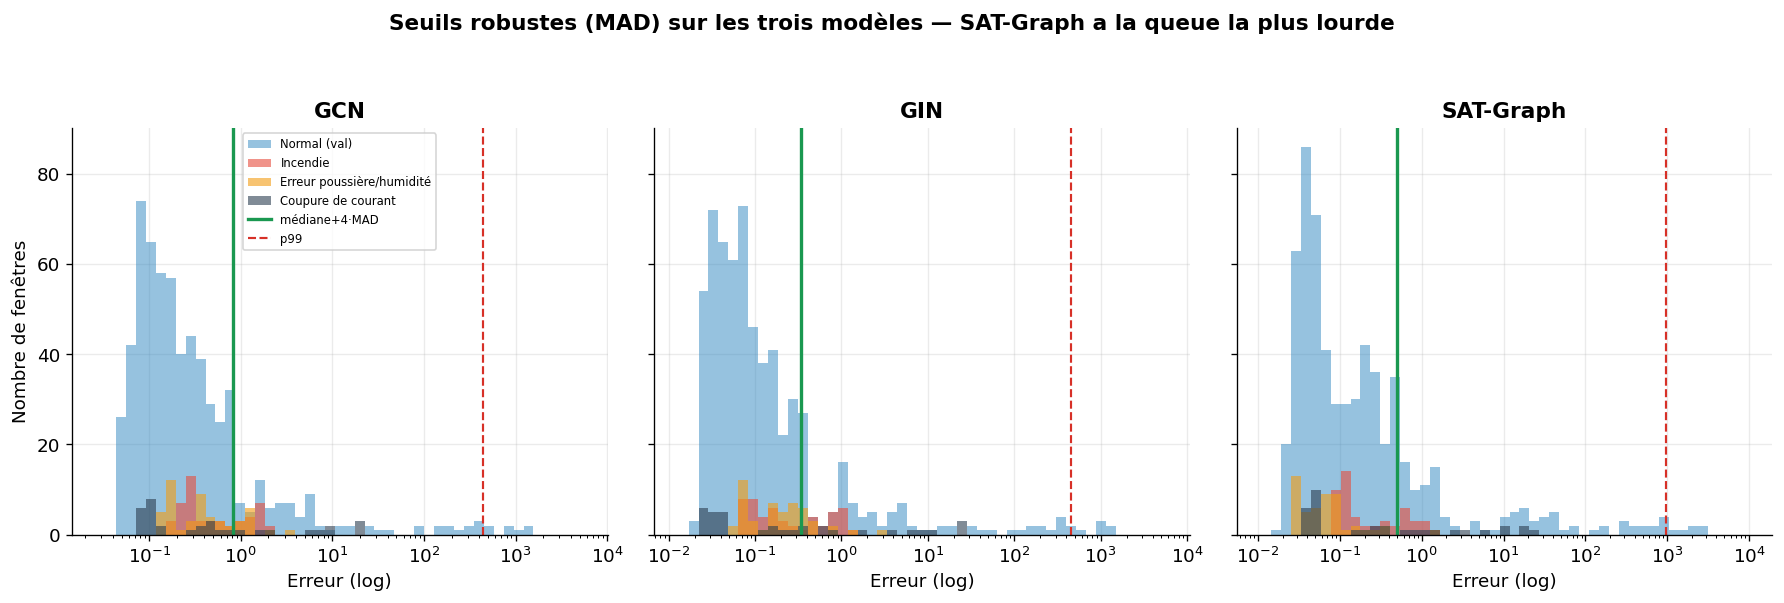

figure : figures\D7_mad_trois_modeles.png


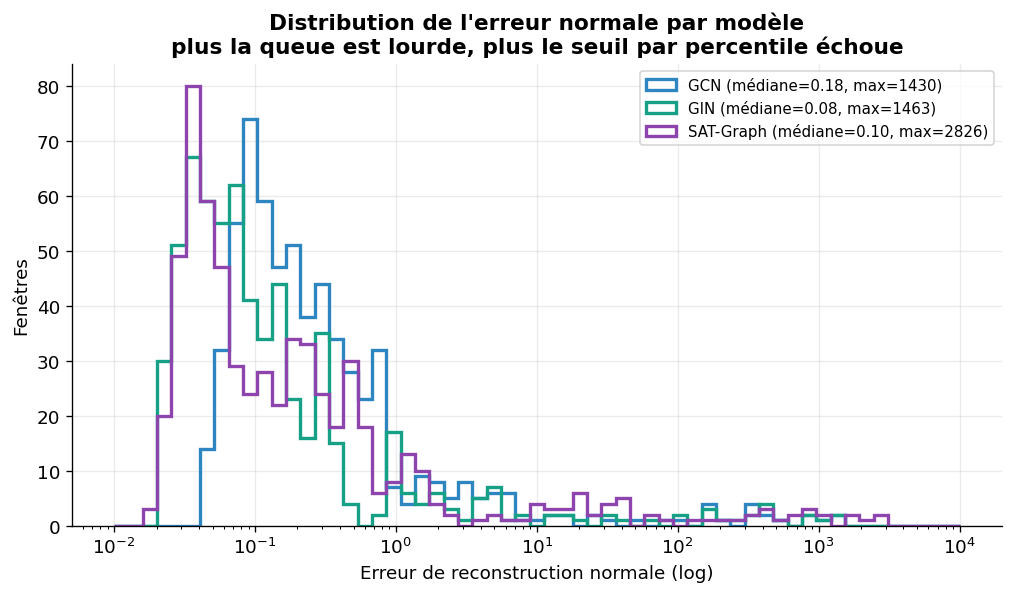

figure : figures\D8_distribution_erreur_par_modele.png


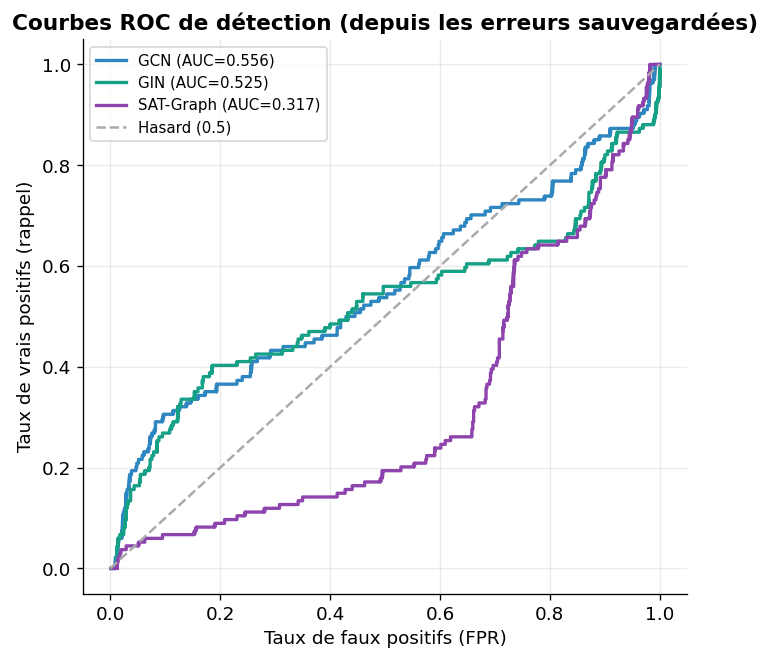

figure : figures\D9_courbes_roc.png


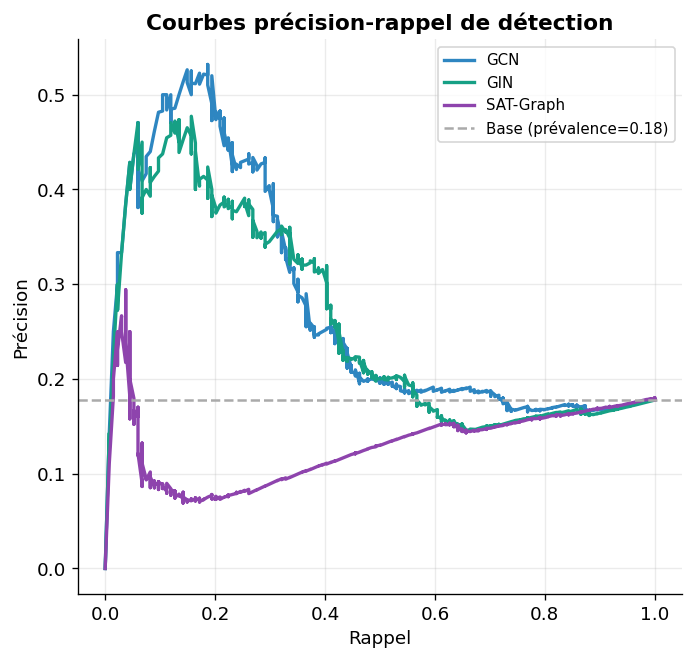

figure : figures\D10_courbes_pr.png


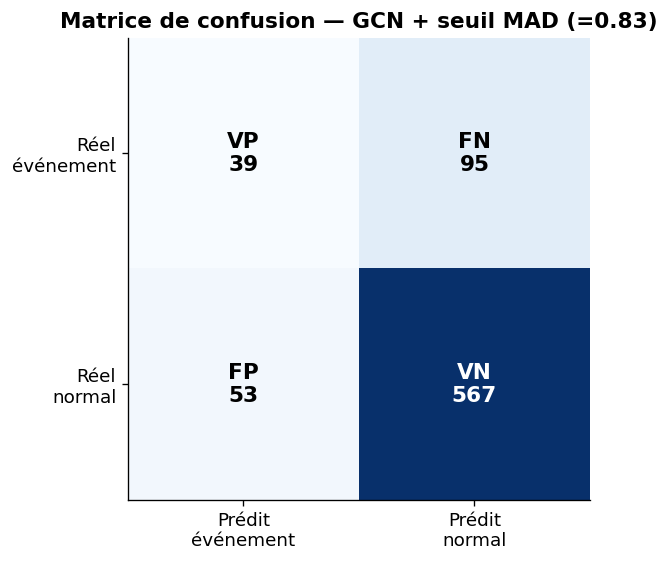

figure : figures\D11_matrice_confusion.png


In [5]:
# Variables du groupe D (erreurs sauvegardées + masques)
Z=np.load(GRAPH/"recon_errors.npz",allow_pickle=True)
det_val=Z["det_val"]; det_test=Z["det_test"]; eid=Z["event_id"]
evn={0:"normal",1:"fire",2:"dust_humidity",3:"power_outage"}
MODELS=["GCN","GIN","SAT-Graph"]

def D7_mad_all_models():
    fig,axes=plt.subplots(1,3,figsize=(15,4.8),sharey=True)
    for ax,m in zip(axes,MODELS):
        err=Z[m]; val=err[det_val]
        bins=np.logspace(np.log10(err.min()+1e-6),np.log10(err.max()),50)
        ax.hist(val,bins=bins,color="#2e86c1",alpha=0.5,label="Normal (val)")
        for k in [1,2,3]:
            ax.hist(err[(eid==k)&det_test],bins=bins,alpha=0.6,color=EVENT_COLORS[evn[k]],label=EVENT_FR[evn[k]])
        med=np.median(val); mad=np.median(np.abs(val-med))
        ax.axvline(med+4*1.4826*mad,color="#1a9850",lw=2,label="médiane+4·MAD")
        ax.axvline(np.percentile(val,99),color="#d73027",ls="--",lw=1.3,label="p99")
        ax.set_xscale("log"); ax.set_title(m); ax.set_xlabel("Erreur (log)")
    axes[0].set_ylabel("Nombre de fenêtres"); axes[0].legend(fontsize=7)
    fig.suptitle("Seuils robustes (MAD) sur les trois modèles — SAT-Graph a la queue la plus lourde",
                 fontsize=13,fontweight="bold",y=1.04); fig.tight_layout(rect=[0,0,1,0.99])
    return save(fig,"D7_mad_trois_modeles.png")

def D8_error_dist_per_model():
    fig,ax=plt.subplots(figsize=(10,5))
    for m,c in zip(MODELS,["#2e86c1","#16a085","#8e44ad"]):
        val=Z[m][det_val]
        ax.hist(val,bins=np.logspace(-2,4,60),histtype="step",lw=2,color=c,
                label=f"{m} (médiane={np.median(val):.2f}, max={val.max():.0f})")
    ax.set_xscale("log"); ax.set_xlabel("Erreur de reconstruction normale (log)"); ax.set_ylabel("Fenêtres")
    ax.set_title("Distribution de l'erreur normale par modèle\nplus la queue est lourde, plus le seuil par percentile échoue")
    ax.legend(fontsize=9)
    return save(fig,"D8_distribution_erreur_par_modele.png")

def _roc_pr(err):
    pos=(eid!=0)&det_test; neg=(eid==0)&det_test
    ep=err[pos]; en=err[neg]
    thr=np.unique(np.concatenate([ep,en])); thr=np.sort(thr)
    tpr=[]; fpr=[]; prec=[]; rec=[]
    P=pos.sum(); N=neg.sum()
    for tt in thr:
        tp=(ep>=tt).sum(); fp=(en>=tt).sum()
        tpr.append(tp/P); fpr.append(fp/N)
        prec.append(tp/(tp+fp) if (tp+fp)>0 else 1.0); rec.append(tp/P)
    return np.array(fpr),np.array(tpr),np.array(rec),np.array(prec)

def D9_roc():
    fig,ax=plt.subplots(figsize=(6.5,6))
    for m,c in zip(MODELS,["#2e86c1","#16a085","#8e44ad"]):
        fpr,tpr,_,_=_roc_pr(Z[m])
        order=np.argsort(fpr); fpr,tpr=fpr[order],tpr[order]
        auc=np.trapezoid(tpr,fpr) if hasattr(np,'trapezoid') else np.trapz(tpr,fpr)
        ax.plot(fpr,tpr,lw=2,color=c,label=f"{m} (AUC={abs(auc):.3f})")
    ax.plot([0,1],[0,1],"--",color="#aaa",label="Hasard (0.5)")
    ax.set_xlabel("Taux de faux positifs (FPR)"); ax.set_ylabel("Taux de vrais positifs (rappel)")
    ax.set_title("Courbes ROC de détection (depuis les erreurs sauvegardées)"); ax.legend(fontsize=9)
    return save(fig,"D9_courbes_roc.png")

def D10_pr():
    fig,ax=plt.subplots(figsize=(6.5,6))
    for m,c in zip(MODELS,["#2e86c1","#16a085","#8e44ad"]):
        _,_,rec,prec=_roc_pr(Z[m])
        order=np.argsort(rec); rec,prec=rec[order],prec[order]
        ax.plot(rec,prec,lw=2,color=c,label=m)
    base=((eid!=0)&det_test).sum()/det_test.sum()
    ax.axhline(base,ls="--",color="#aaa",label=f"Base (prévalence={base:.2f})")
    ax.set_xlabel("Rappel"); ax.set_ylabel("Précision")
    ax.set_title("Courbes précision-rappel de détection"); ax.legend(fontsize=9)
    return save(fig,"D10_courbes_pr.png")

def D11_confusion():
    err=Z["GCN"]; val=err[det_val]; med=np.median(val); mad=np.median(np.abs(val-med))
    thr=med+4*1.4826*mad
    pos=(eid!=0)&det_test; neg=(eid==0)&det_test
    tp=int((err[pos]>=thr).sum()); fn=int((err[pos]<thr).sum())
    fp=int((err[neg]>=thr).sum()); tn=int((err[neg]<thr).sum())
    M=np.array([[tp,fn],[fp,tn]])
    fig,ax=plt.subplots(figsize=(6,5))
    im=ax.imshow(M,cmap="Blues")
    labels=[["VP","FN"],["FP","VN"]]
    for i in range(2):
        for j in range(2):
            ax.text(j,i,f"{labels[i][j]}\n{M[i,j]}",ha="center",va="center",fontsize=13,
                    color="white" if M[i,j]>M.max()/2 else "black",fontweight="bold")
    ax.set_xticks([0,1]); ax.set_xticklabels(["Prédit\névénement","Prédit\nnormal"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["Réel\névénement","Réel\nnormal"])
    ax.set_title(f"Matrice de confusion — GCN + seuil MAD (={thr:.2f})"); ax.grid(False)
    return save(fig,"D11_matrice_confusion.png")

# ===================== E-series =====================

for f in [D7_mad_all_models,D8_error_dist_per_model,D9_roc,D10_pr,D11_confusion]: f()

## Groupe E — Prédiction (figures supplémentaires)

**E3/E4** : RMSE et MAE par polluant (unités réelles). **E5** : quel modèle gagne pour chaque polluant
(bleu = GNN, orange = séquentiel). **E6** : distribution des valeurs cibles réelles, qui illustre
l'échelle et la difficulté de la régression.

--- A ---


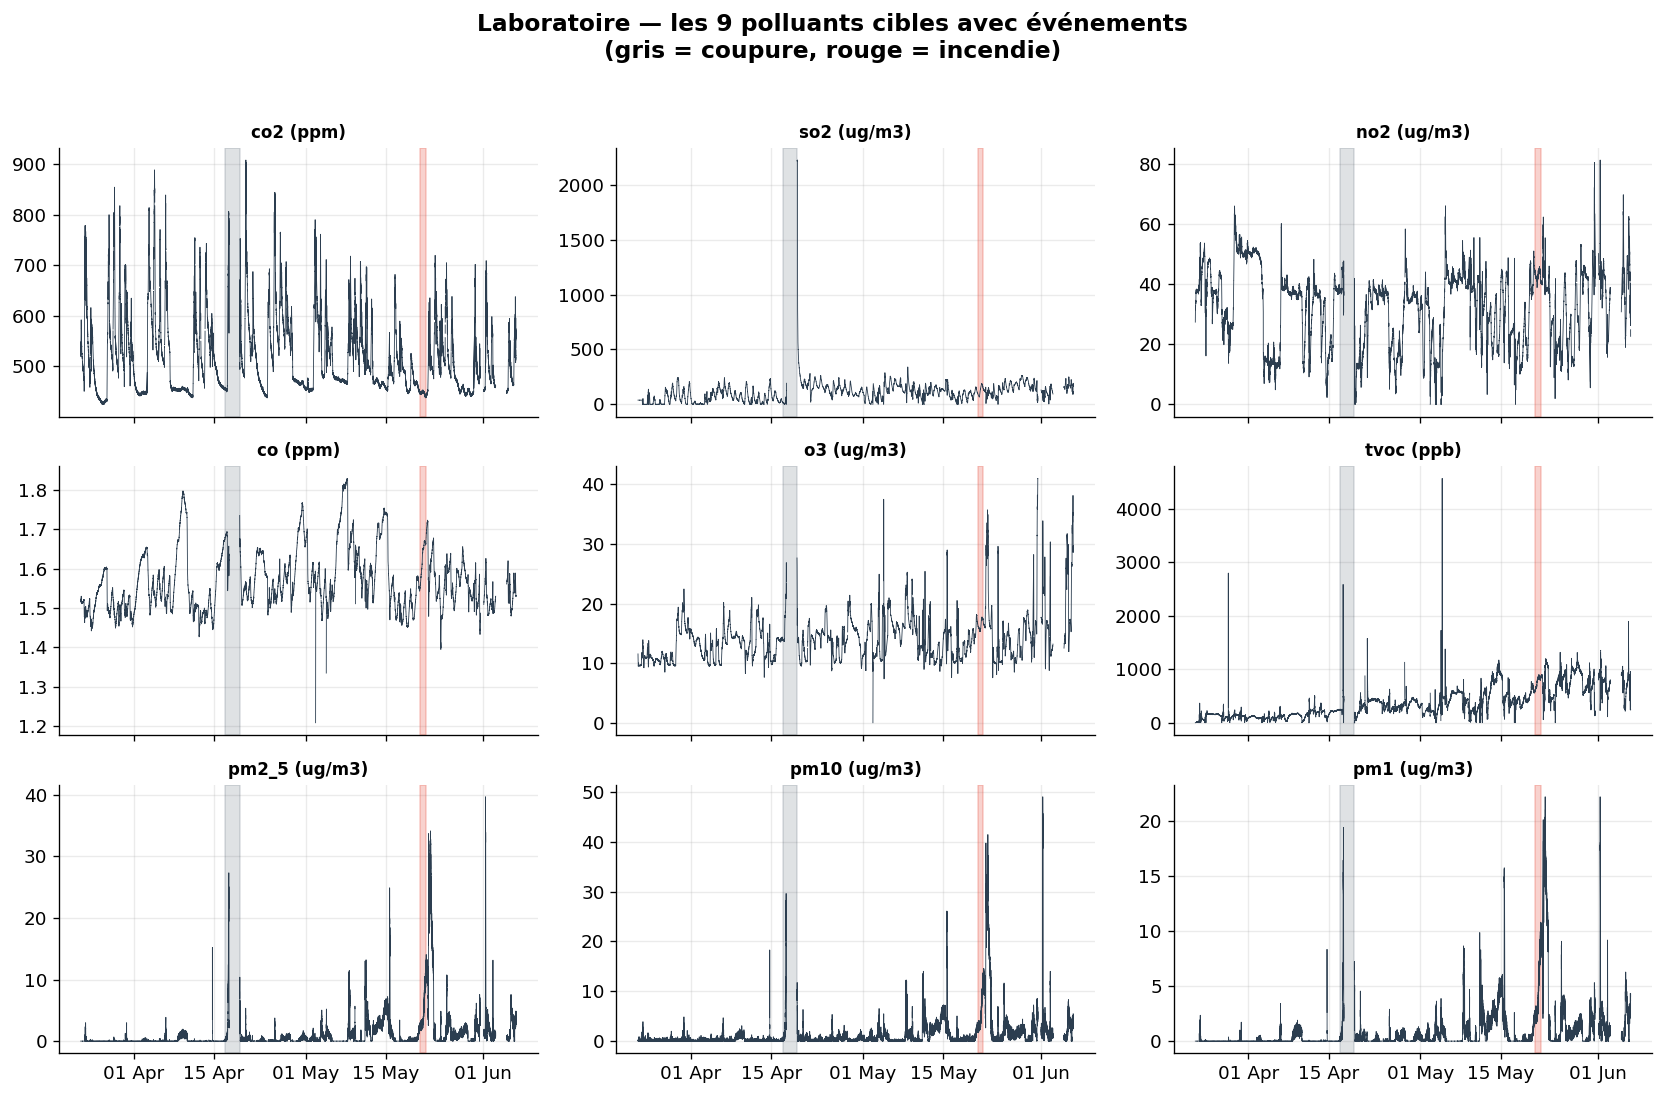

figure : figures\A7_tous_polluants.png


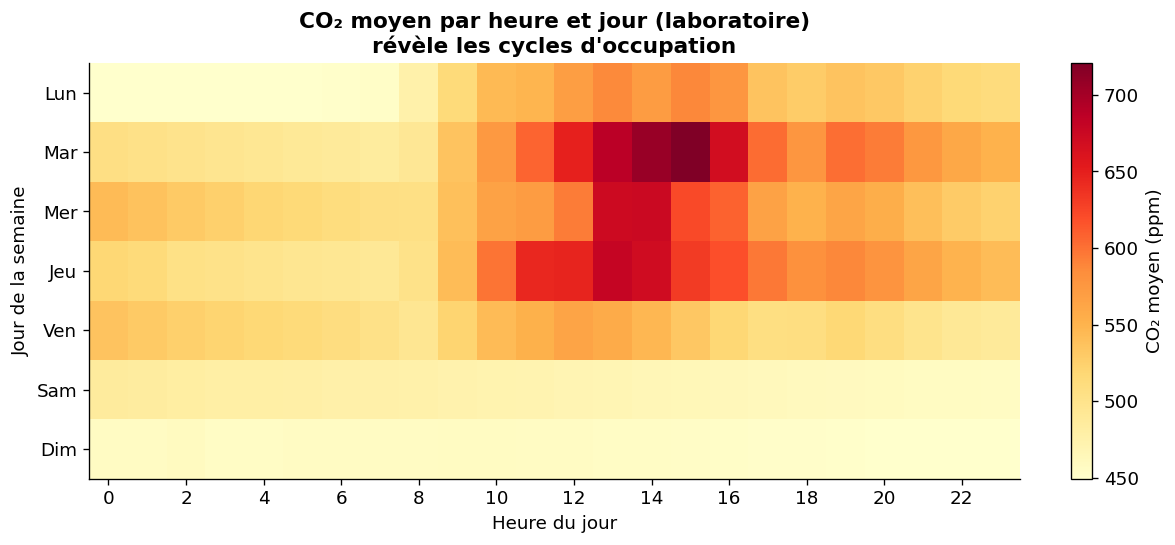

figure : figures\A8_co2_heure_jour.png


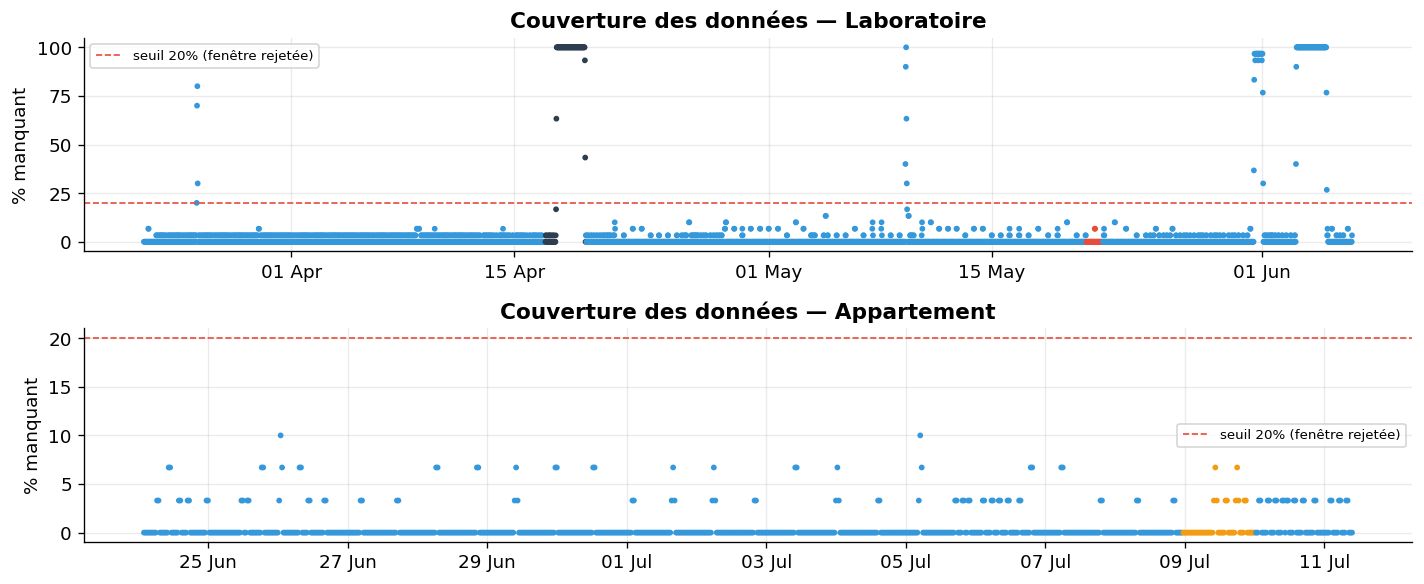

figure : figures\A9_couverture_donnees.png


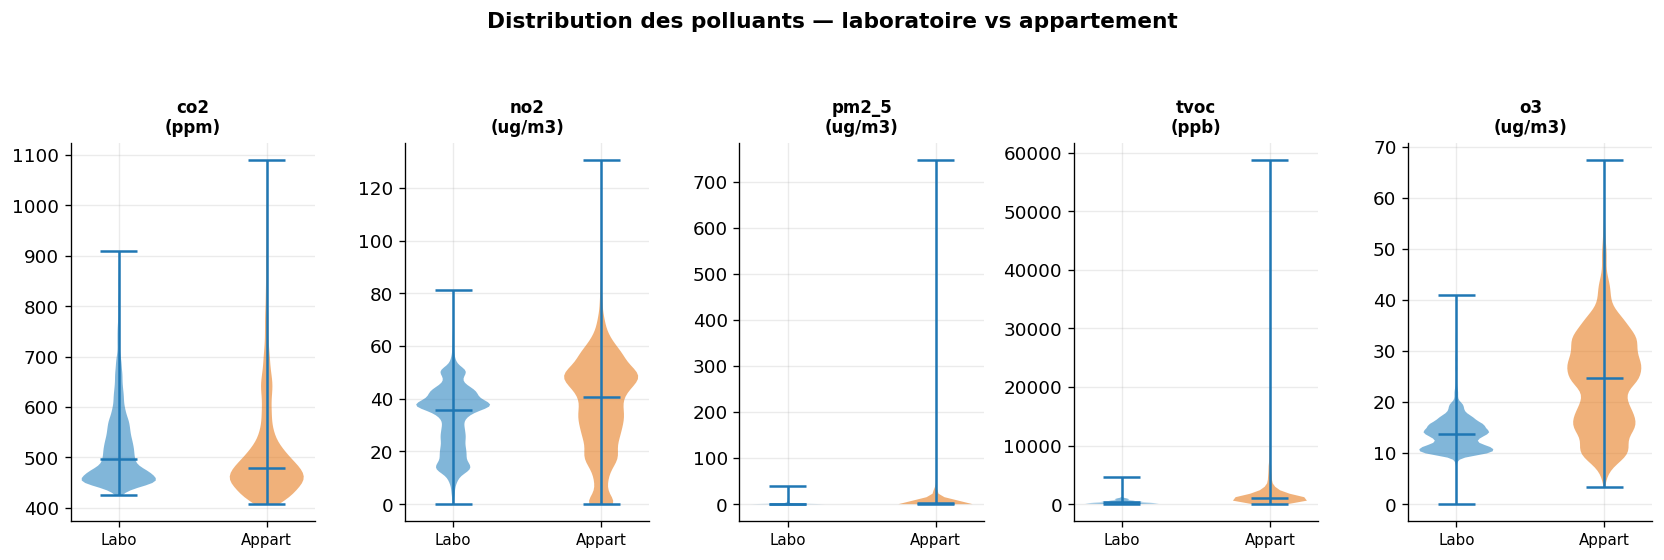

figure : figures\A10_distributions_labo_appart.png
--- B ---


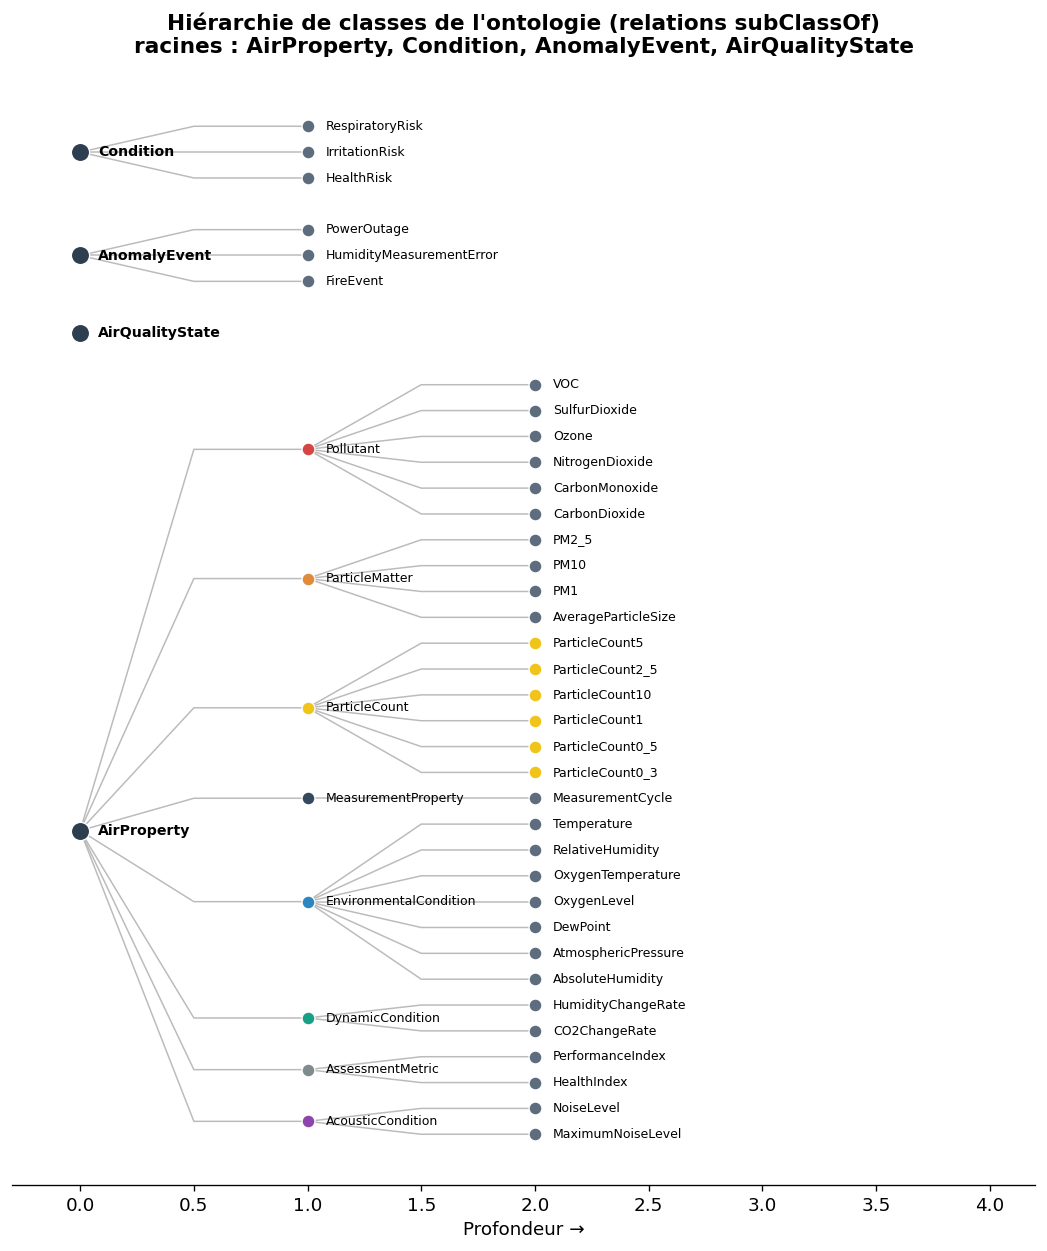

figure : figures\B3_hierarchie_classes.png


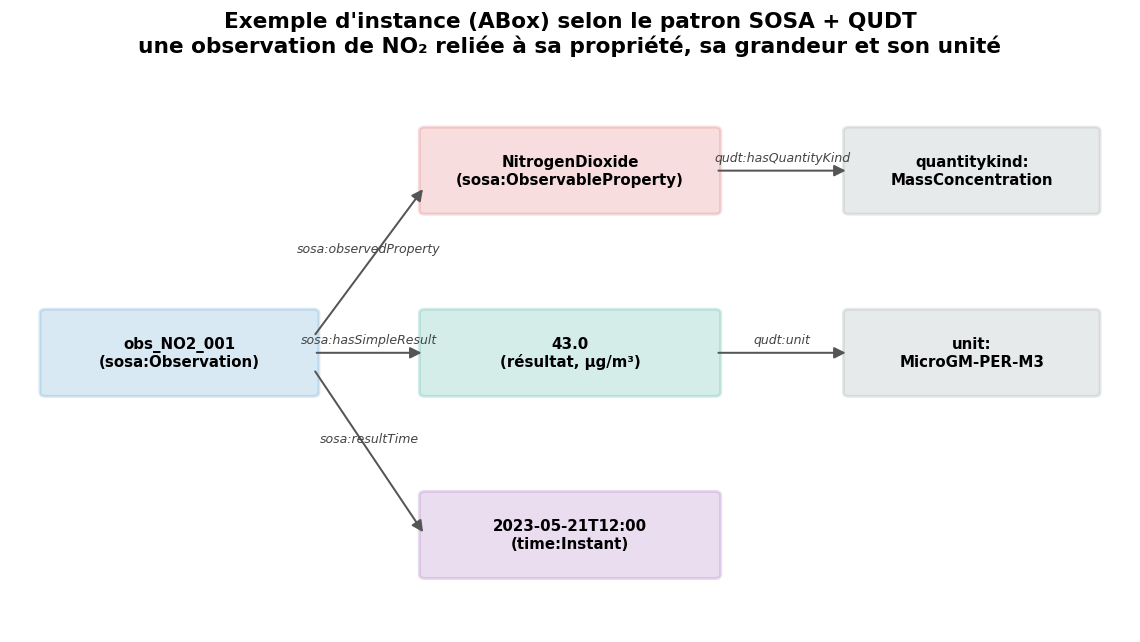

figure : figures\B4_exemple_abox_sosa.png


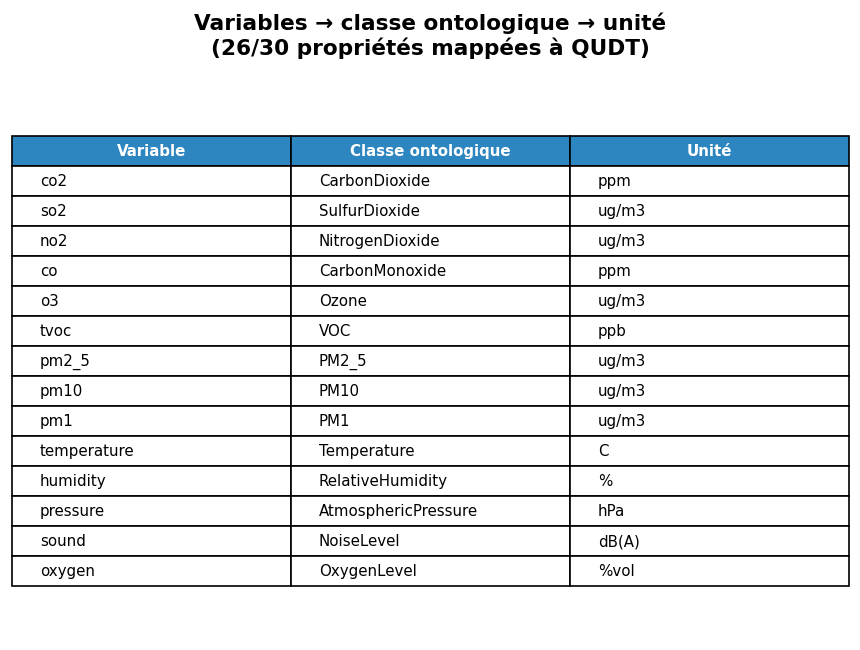

figure : figures\B5_table_unites_qudt.png
--- C ---


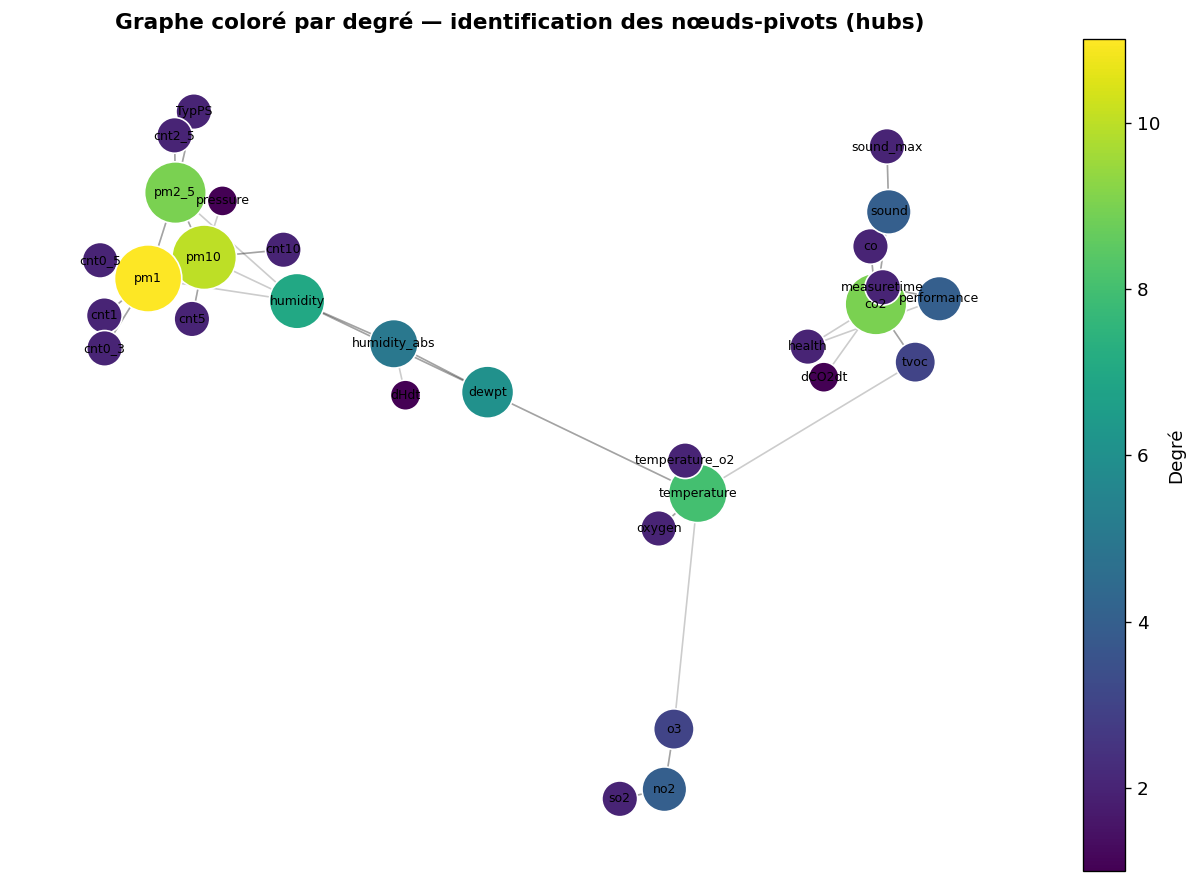

figure : figures\C4_graphe_par_degre.png


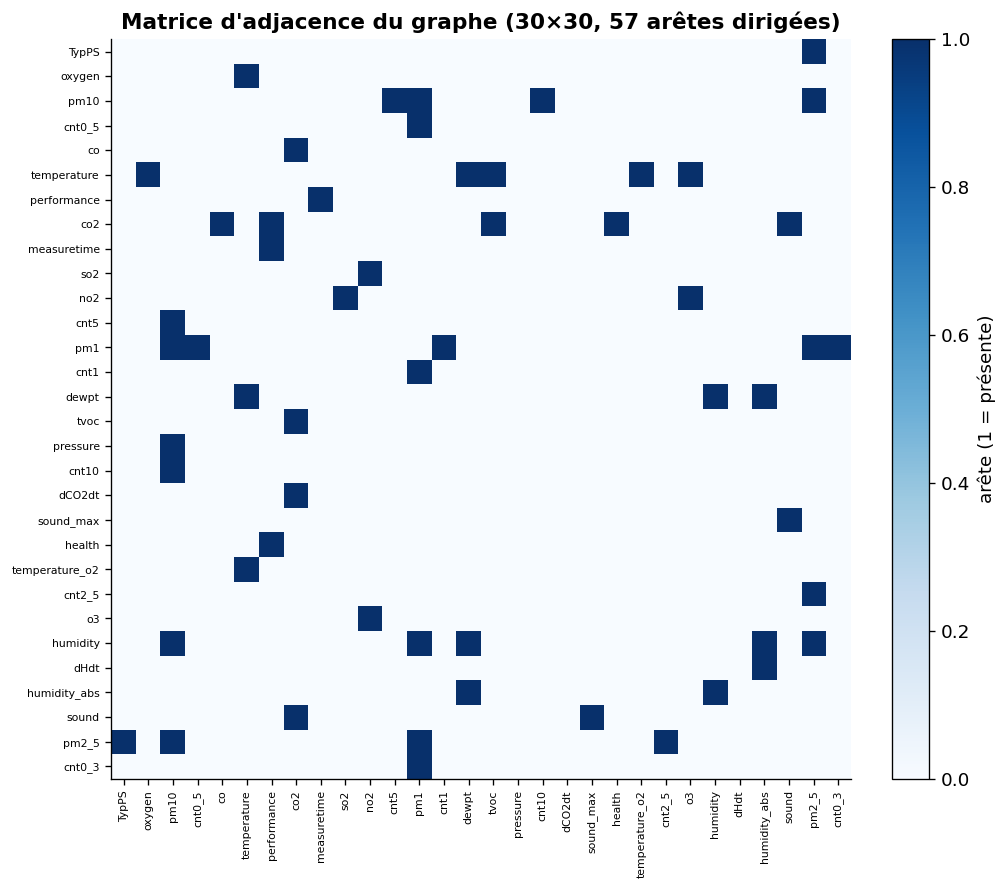

figure : figures\C5_matrice_adjacence.png


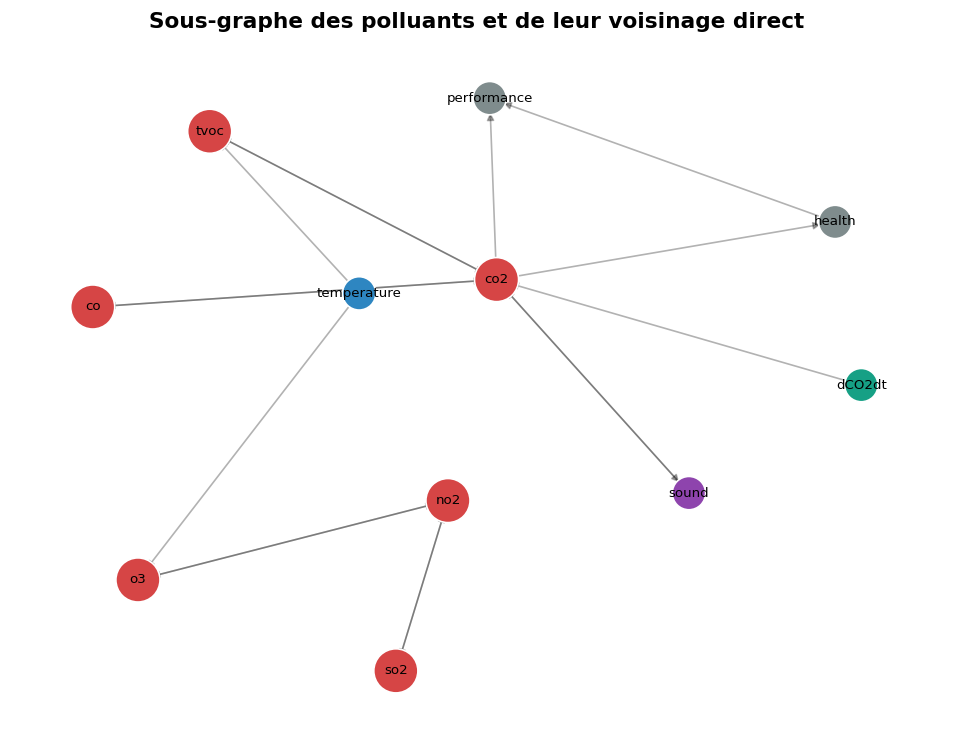

figure : figures\C6_sous_graphe_polluants.png
--- D ---


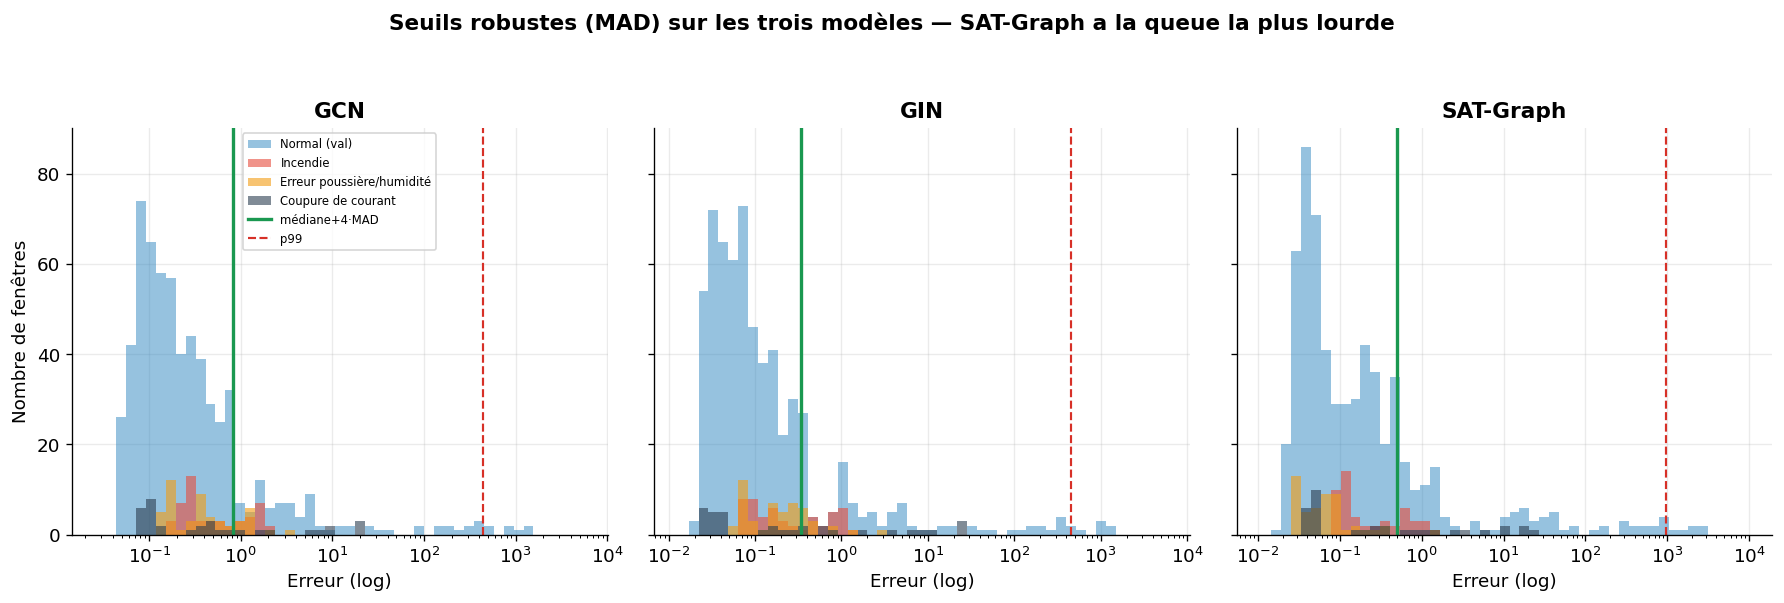

figure : figures\D7_mad_trois_modeles.png


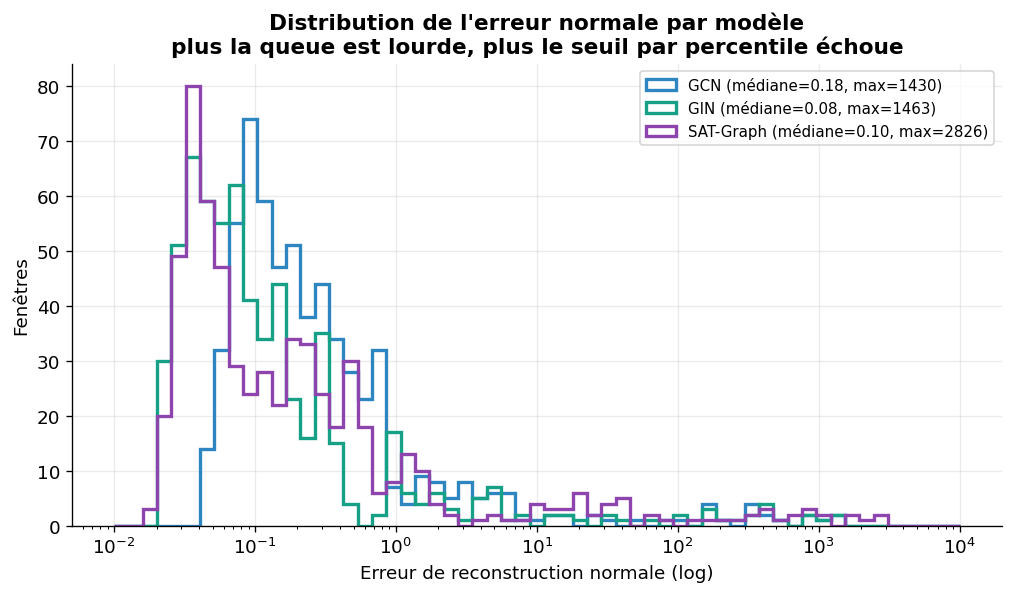

figure : figures\D8_distribution_erreur_par_modele.png


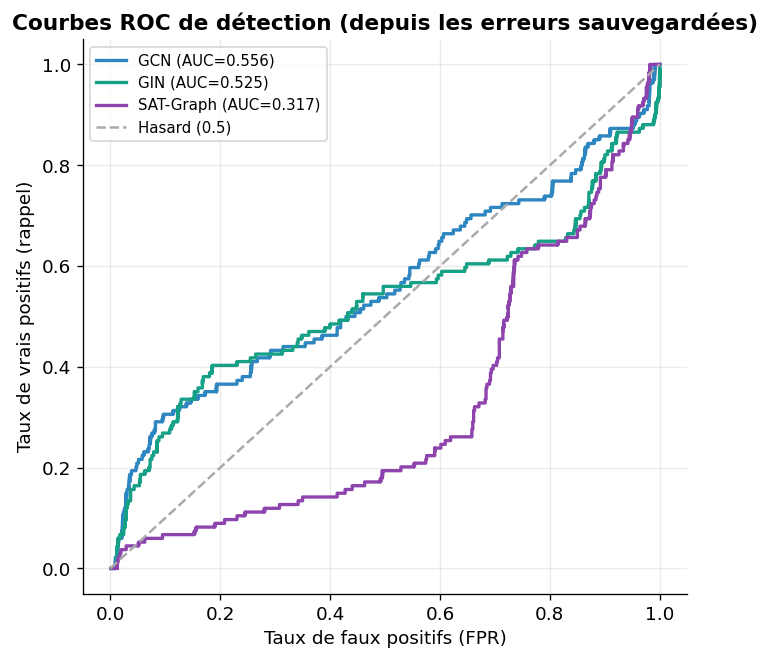

figure : figures\D9_courbes_roc.png


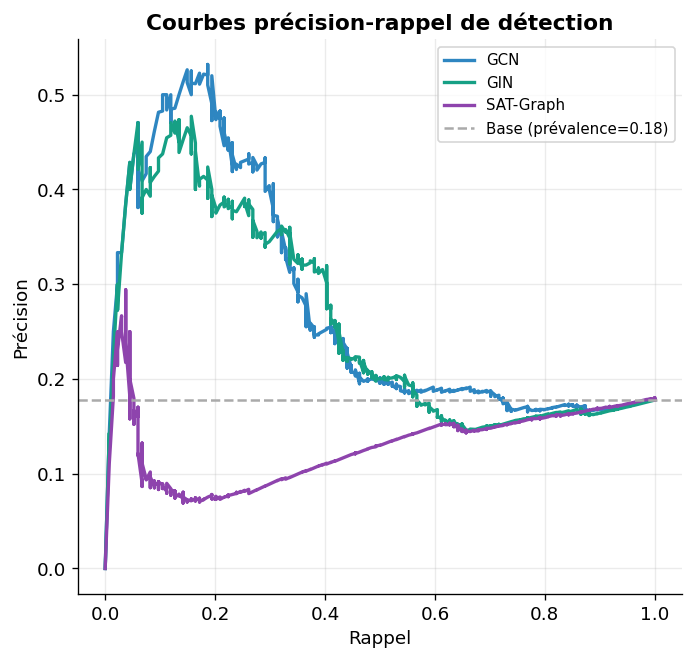

figure : figures\D10_courbes_pr.png


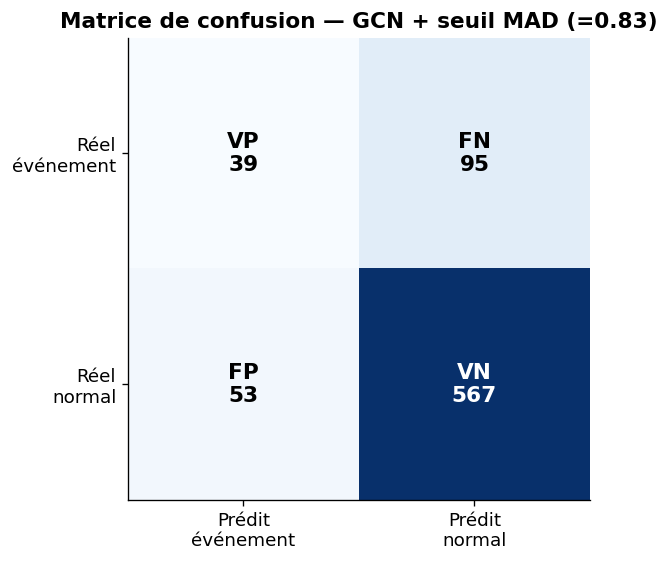

figure : figures\D11_matrice_confusion.png
--- E ---


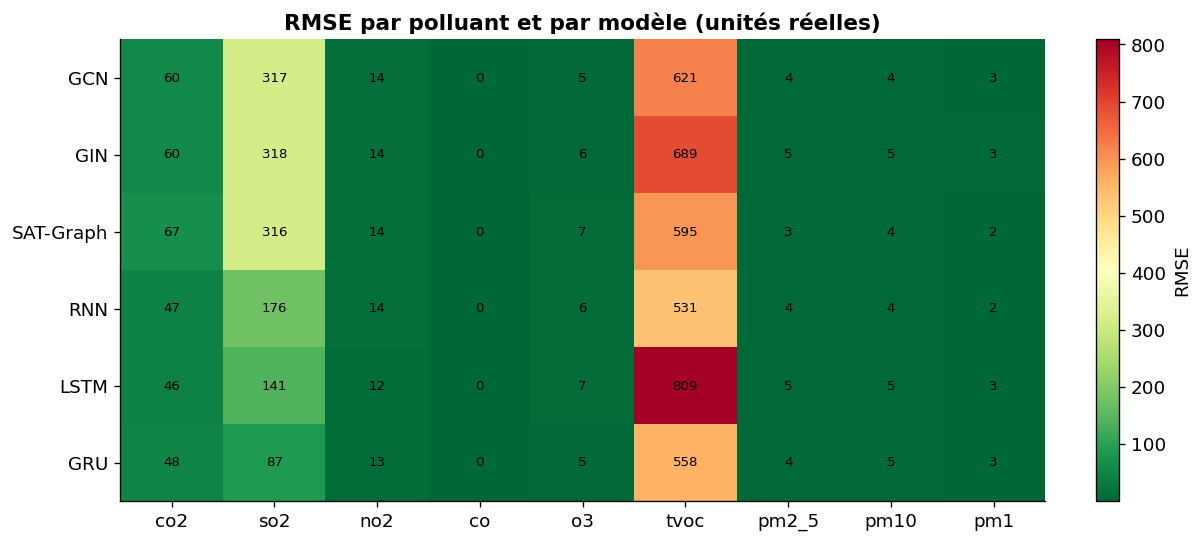

figure : figures\E3_rmse_heatmap.png


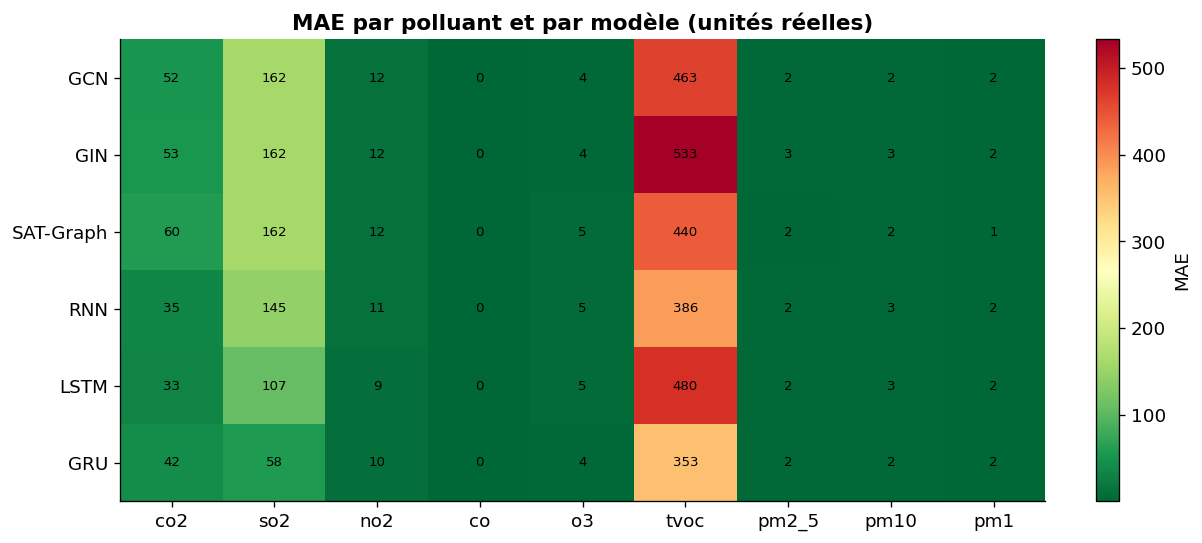

figure : figures\E4_mae_heatmap.png


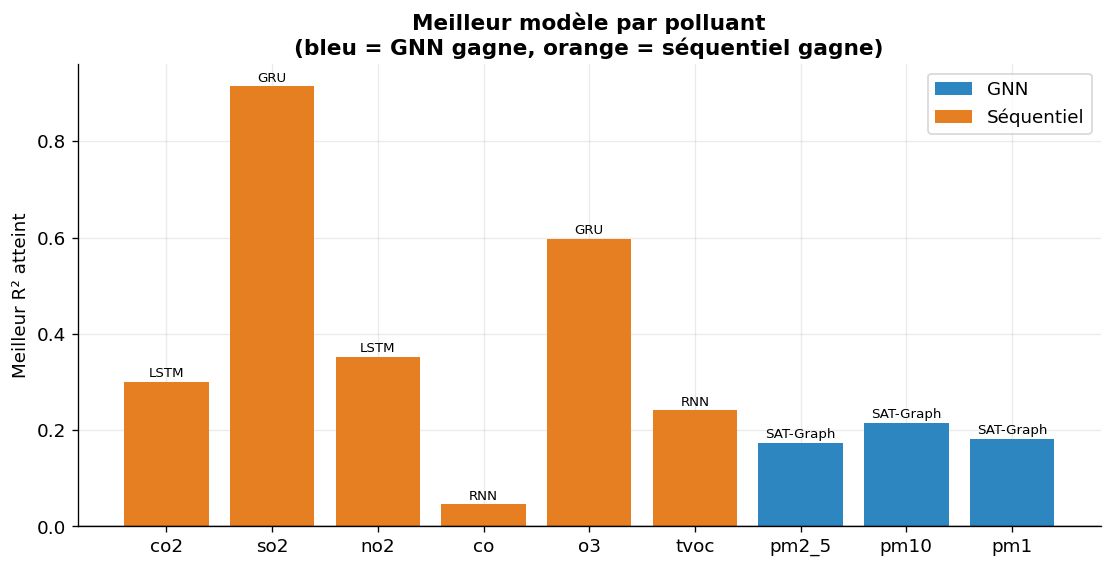

figure : figures\E5_meilleur_par_polluant.png


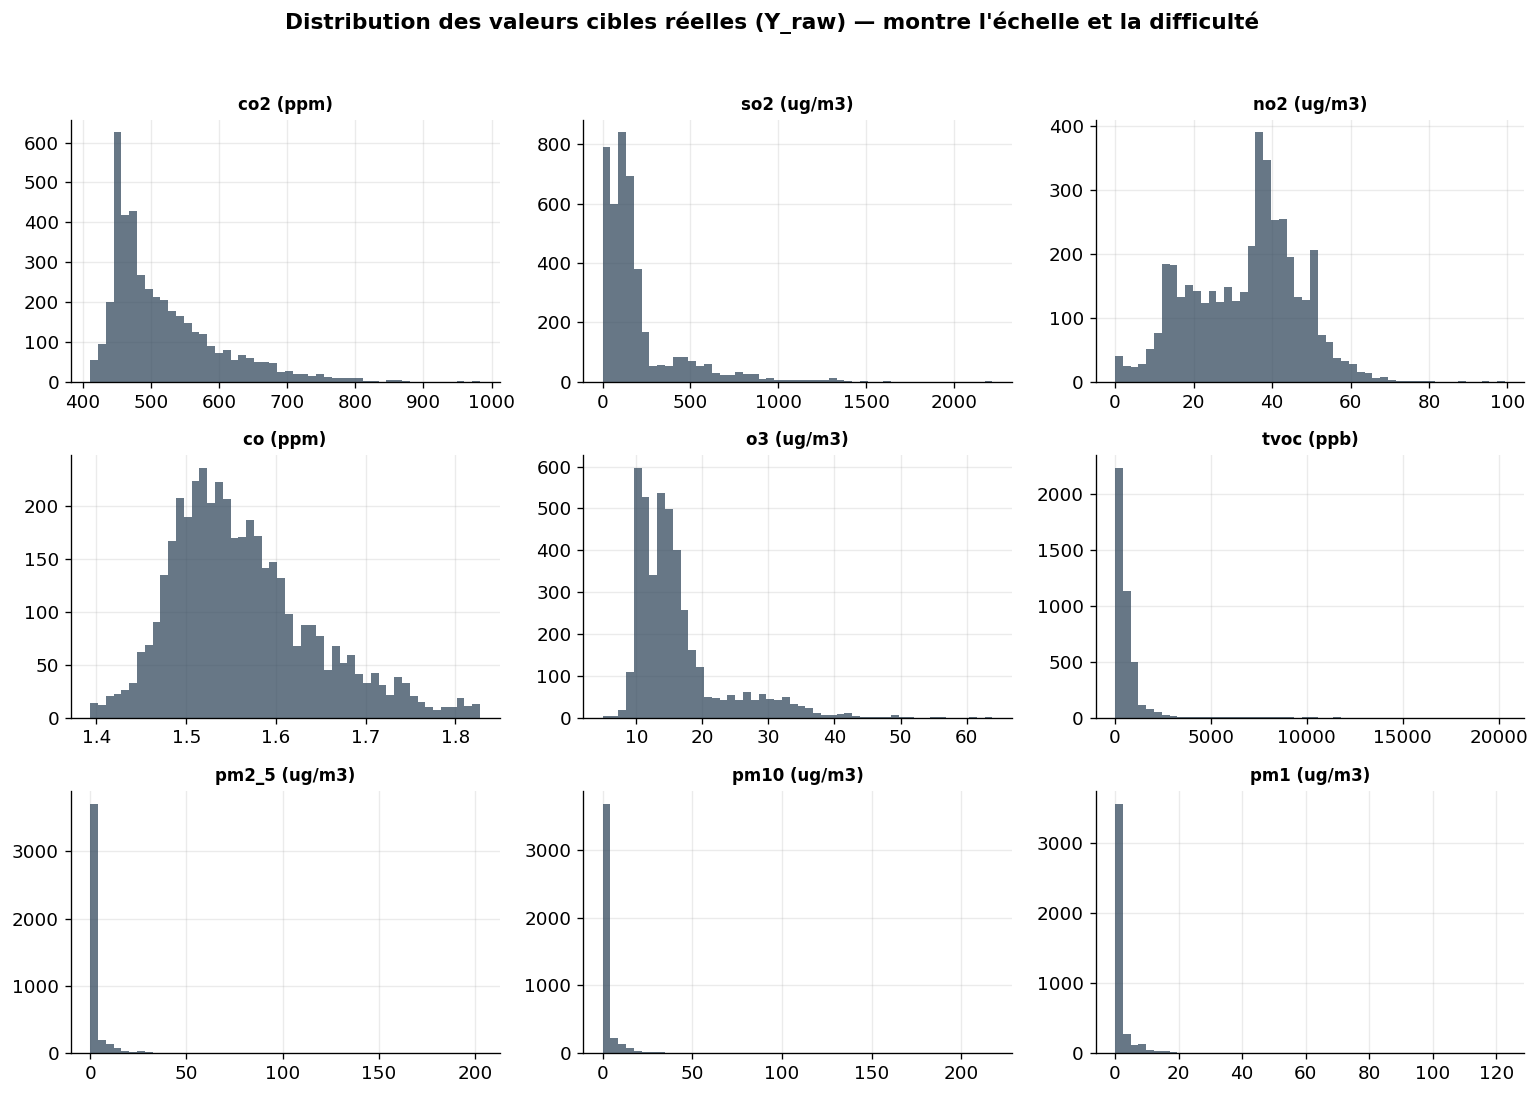

figure : figures\E6_distribution_cibles.png

==> 19 figures supplémentaires


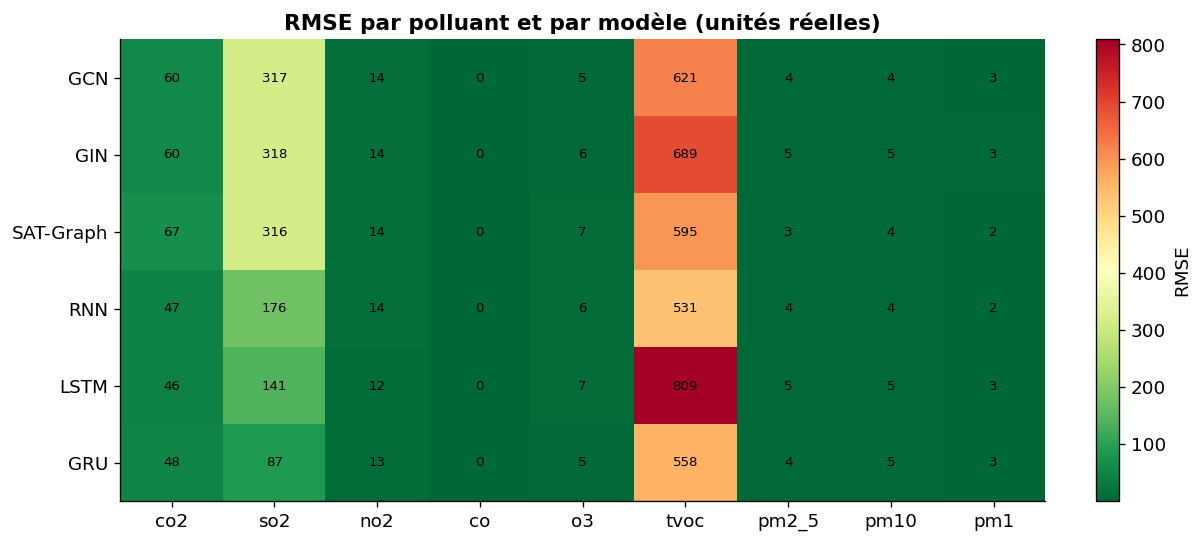

figure : figures\E3_rmse_heatmap.png


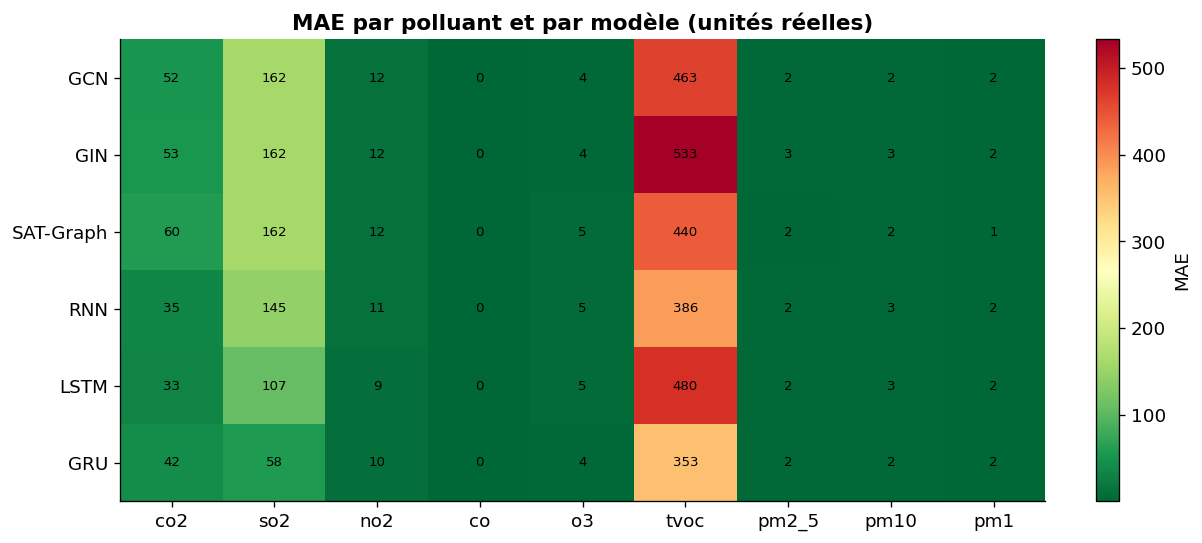

figure : figures\E4_mae_heatmap.png


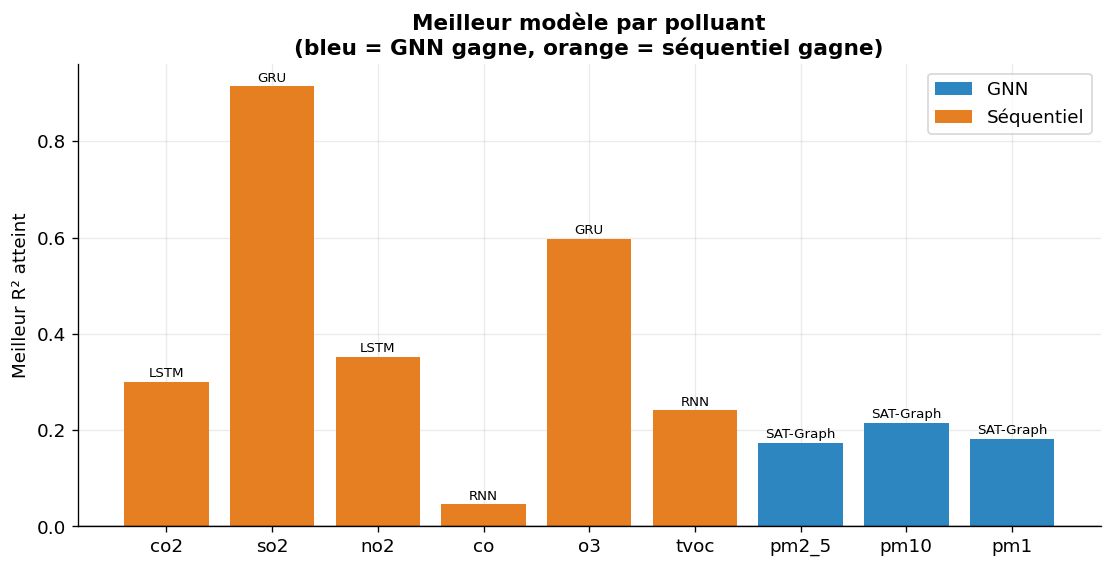

figure : figures\E5_meilleur_par_polluant.png


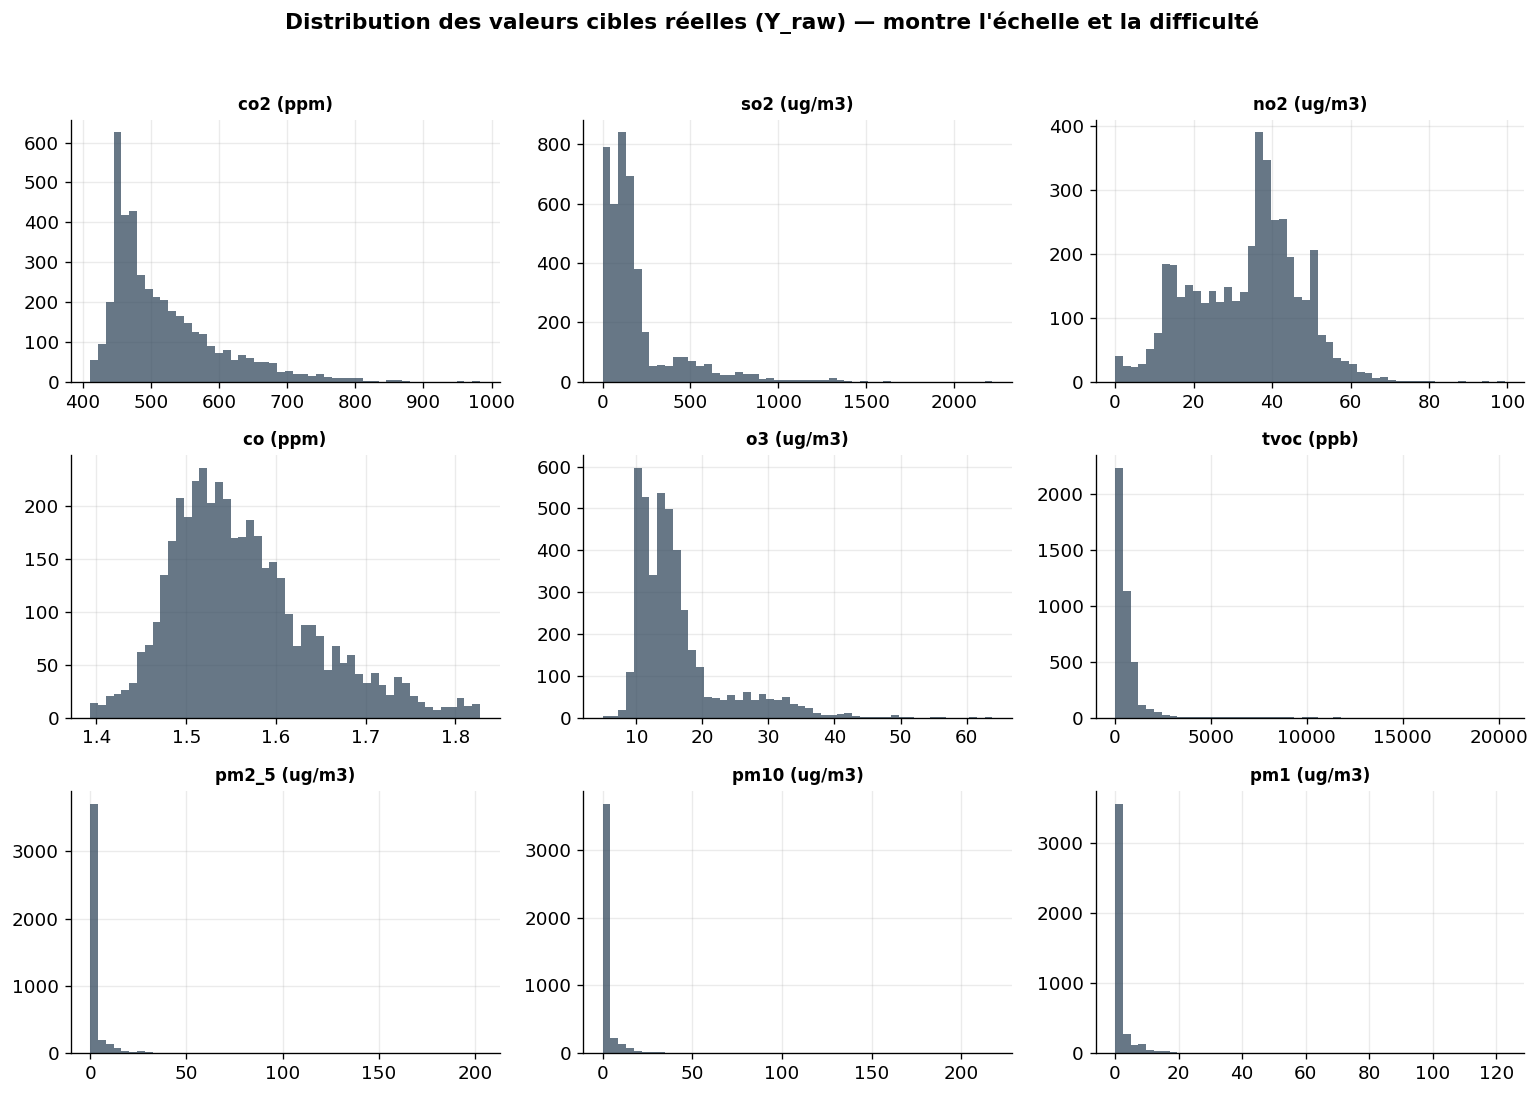

figure : figures\E6_distribution_cibles.png

=== Figures supplémentaires générées dans figures/ ===


In [6]:
def E3_rmse_heatmap():
    df=pd.read_csv(GRAPH/"nb05_pred_rmse.csv").set_index("Model")
    polls=[c for c in df.columns if c!="AVG"]; M=df[polls].values
    fig,ax=plt.subplots(figsize=(11,5))
    im=ax.imshow(M,cmap="RdYlGn_r",aspect="auto")
    ax.set_xticks(range(len(polls))); ax.set_xticklabels(polls)
    ax.set_yticks(range(len(df.index))); ax.set_yticklabels(df.index)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j,i,f"{M[i,j]:.0f}",ha="center",va="center",fontsize=8)
    ax.set_title("RMSE par polluant et par modèle (unités réelles)"); ax.grid(False)
    fig.colorbar(im,ax=ax,fraction=0.046,label="RMSE")
    return save(fig,"E3_rmse_heatmap.png")

def E4_mae_heatmap():
    df=pd.read_csv(GRAPH/"nb05_pred_mae.csv").set_index("Model")
    polls=[c for c in df.columns if c!="AVG"]; M=df[polls].values
    fig,ax=plt.subplots(figsize=(11,5))
    im=ax.imshow(M,cmap="RdYlGn_r",aspect="auto")
    ax.set_xticks(range(len(polls))); ax.set_xticklabels(polls)
    ax.set_yticks(range(len(df.index))); ax.set_yticklabels(df.index)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j,i,f"{M[i,j]:.0f}",ha="center",va="center",fontsize=8)
    ax.set_title("MAE par polluant et par modèle (unités réelles)"); ax.grid(False)
    fig.colorbar(im,ax=ax,fraction=0.046,label="MAE")
    return save(fig,"E4_mae_heatmap.png")

def E5_best_per_pollutant():
    df=pd.read_csv(GRAPH/"nb05_pred_r2.csv").set_index("Model")
    polls=[c for c in df.columns if c!="AVG"]
    best=df[polls].idxmax(); bestval=df[polls].max()
    fam={"GCN":"GNN","GIN":"GNN","SAT-Graph":"GNN","RNN":"Seq","LSTM":"Seq","GRU":"Seq"}
    colors=["#2e86c1" if fam[best[p]]=="GNN" else "#e67e22" for p in polls]
    fig,ax=plt.subplots(figsize=(11,5))
    bars=ax.bar(polls,bestval.values,color=colors)
    for b,p in zip(bars,polls):
        ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.01,best[p],ha="center",fontsize=8,rotation=0)
    ax.axhline(0,color="k",lw=0.8); ax.set_ylabel("Meilleur R² atteint")
    ax.set_title("Meilleur modèle par polluant\n(bleu = GNN gagne, orange = séquentiel gagne)")
    ax.legend(handles=[Patch(facecolor="#2e86c1",label="GNN"),Patch(facecolor="#e67e22",label="Séquentiel")])
    return save(fig,"E5_meilleur_par_polluant.png")

def E6_target_dist():
    z=np.load(GRAPH/"graph_windows.npz",allow_pickle=True)
    Y=z["Y_raw"]  # (4258, 9)
    fig,axes=plt.subplots(3,3,figsize=(13,9))
    for ax,(i,c) in zip(axes.ravel(),enumerate(TARGETS)):
        ax.hist(Y[:,i],bins=50,color="#34495e",alpha=0.75)
        ax.set_title(f"{c} ({units.get(c,'')})",fontsize=10)
    fig.suptitle("Distribution des valeurs cibles réelles (Y_raw) — montre l'échelle et la difficulté",
                 fontsize=13,fontweight="bold",y=1.01); fig.tight_layout(rect=[0,0,1,0.99])
    return save(fig,"E6_distribution_cibles.png")

# ===================== run =====================
print("--- A ---");  [t(f) for f in [A7_all_pollutants,A8_hour_heatmap,A9_gap_map,A10_violin]]
print("--- B ---");  [t(f) for f in [B3_hierarchy,B4_abox_sample,B5_qudt_table]]
print("--- C ---");  [t(f) for f in [C4_graph_by_degree,C5_adjacency,C6_pollutant_subgraph]]
print("--- D ---");  [t(f) for f in [D7_mad_all_models,D8_error_dist_per_model,D9_roc,D10_pr,D11_confusion]]
print("--- E ---");  [t(f) for f in [E3_rmse_heatmap,E4_mae_heatmap,E5_best_per_pollutant,E6_target_dist]]
print(f"\n==> {len(done)} figures supplémentaires")

for f in [E3_rmse_heatmap,E4_mae_heatmap,E5_best_per_pollutant,E6_target_dist]: f()
print("\n=== Figures supplémentaires générées dans figures/ ===")

---
### Fin du Notebook 7B

Avec le Notebook 7, vous disposez désormais de **39 figures** au total, toutes issues des résultats
réels. Pour le rapport, les ajouts les plus utiles sont : **B3** et **B4** (ontologie), **D9** (ROC,
qui résume la difficulté de la détection), **D7** (pourquoi SAT-Graph échoue) et **E5** (qui gagne
par polluant).